**기계학습기초 팀 프로젝트**

**KNHANES 2022 자가보고식 건강 설문 기반 우울 위험군 선별 가능성 탐색**

- 팀명: 5팀
- 데이터: 국민건강영양조사 제9기 1차년도(2022년)
- 사용 데이터 형태: 이미 하나의 데이터셋으로 병합된 KNHANES 원시자료
- 주제: 자가보고식 건강 설문 기반 우울 위험군 선별 가능성 탐색
- 최종 산출물: 데이터 분석 전 과정을 포함한 Jupyter Notebook

> 이 노트북에서 사용하는 **“조기 선별”**의 의미와 연구 범위는 `1.4 연구 범위: 조기 선별의 의미`에서 별도로 정의한다.


**분석 구성 요약**

- KNHANES 2022 자료에서 수면시간, 청각 문제, 소음 노출 관련 변수를 선별하였다.
- PHQ-9 수면 문항 `phq_3`을 제외해 계산한 PHQ8 총점을 기준으로 우울 위험군을 정의하였다.
- 특히 본 연구에서는 수면시간 변수를 입력 변수로 사용하기 때문에, PHQ-9 문항 중 수면 문항인 `phq_3`을 제외하고 PHQ8 총점을 계산하였다. 이는 수면시간 변수와 타깃 변수 사이의 개념적 중복을 줄이기 위한 처리이다.
- 본 모델은 PHQ-9 또는 PHQ8을 대체하기 위한 도구가 아니다. PHQ-9를 직접 시행할 수 있는 상황에서는 PHQ-9가 가장 직접적인 선별도구이다.
- “조기 선별”의 의미와 연구 범위는 `1.4 연구 범위: 조기 선별의 의미`에서 정의하고, 이후 성능 평가는 이 기준에 따라 해석한다.
- 클래스 불균형을 고려하여 `class_weight`, UnderSampling, threshold 조정을 함께 비교하였다.
- 머신러닝 모델과 PyTorch 기반 Focal MLP를 동일한 평가 흐름에서 비교하였다.
- 최종 평가는 조기 선별 목적에 맞게 Accuracy보다 F2-score, Recall, PR-AUC, False Negative 수를 중심으로 해석한다.


---

# 1. 프로젝트 개요

## 1.1 연구 배경

본 프로젝트는 국민건강영양조사 제9기 1차년도(2022년) 자료를 활용하여 수면시간, 청각 문제, 소음 노출 관련 자기보고 지표가 PHQ8 기준 우울 위험군 선별에 제공하는 정보를 탐색한다.

## 1.2 문제 정의

- 입력 변수: 수면시간, 청각 상태, 직업적 소음 노출, 이명, 이어폰 소음 노출, 청각 활동제한 관련 변수
- 타깃 변수: `depression_risk = phq8_score >= 7` (PHQ8 기준 우울 위험군)
- 문제 유형: 지도학습 기반 이진 분류

## 1.3 분석 목표

- 자가보고식 건강 설문 기반 PHQ8 기준 우울 위험군 선별 가능성 탐색
- 수면·청각·소음 관련 변수의 선별 기여도 확인
- 여러 분류 모델의 성능 비교
- 변수 중요도 및 도메인 관점 해석

## 1.4 연구 범위: “조기 선별”의 의미

본 연구에서의 **조기 선별**은 미래 우울증 발병을 예측한다는 의미가 아니다. 이는 전문적 진단 이전 단계에서 수면·청각·소음 관련 자기보고 지표를 활용하여, 추가 평가가 필요한 **PHQ8 기준 우울 위험군**을 빠르게 가려낼 수 있는지 탐색한다는 의미이다.

따라서 본 프로젝트는 우울증을 확정 진단하는 모델 개발이 아니라, KNHANES 2022 자료를 활용하여 PHQ8 기준 우울 위험군과 수면·청각·소음 관련 자기보고 지표 사이의 연관성을 탐색하고, 해당 변수들이 위험군 선별에 어느 정도 정보를 제공하는지 검토하는 연구로 정리한다.

이 정의는 노트북 전체의 해석 기준이다. 이후 성능 평가에서 사용하는 “조기 선별 모델”이라는 표현도 이 범위 안에서만 해석한다.

## 1.5 분석 시 주의점

본 프로젝트에서는 이미 하나의 파일로 병합된 KNHANES 데이터를 사용하므로 별도의 데이터 병합 과정은 수행하지 않는다. 또한 PHQ-9에는 수면 관련 문항이 포함되어 있으므로, 수면시간 변수와 타깃 간 개념적 중복을 줄이기 위해 수면 문항을 제외한 문항(PHQ8)의 총점을 사용한다.

본 연구는 임상적 우울증 진단을 수행하지 않는다. PHQ-9/PHQ8 자체도 자가보고식 우울 증상 선별도구이며, 선별 결과만으로 임상적 진단을 확정할 수 없다. 따라서 본 연구에서 정의한 우울 위험군 역시 임상적 우울증 진단군이 아니라, PHQ 기반 점수에서 추가 평가가 필요할 가능성이 높은 선별 위험군을 의미한다.

본 모델은 PHQ-9 또는 PHQ8을 대체하기 위한 도구가 아니다. PHQ-9를 직접 시행할 수 있는 상황에서는 PHQ-9가 가장 직접적인 선별도구이다. 본 연구의 의의는 PHQ8 기준 위험군을 기준으로 수면시간, 청각 문제, 소음 노출과 같은 비정신건강 설문 지표들이 위험군 선별에 어느 정도 정보를 제공하는지 탐색했다는 데 있다.


---

# 2. 라이브러리 및 기본 설정


In [37]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
FIGURE_DIR = "figures"
OUTPUT_DIR = "outputs"

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

figure_registry = []


def save_figure(fig, filename, title=None, dpi=150):
    """Save a matplotlib figure into figures/ and record metadata."""
    if not filename.endswith(".png"):
        filename += ".png"
    path = os.path.join(FIGURE_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    if not any(item["filename"] == filename for item in figure_registry):
        figure_registry.append({
            "filename": filename,
            "path": path,
            "title": title if title is not None else filename.replace(".png", ""),
        })
    print(f"Saved figure: {path}")


def save_current_figure(filename, title=None, dpi=150):
    """Save the current matplotlib figure into figures/ and record metadata."""
    save_figure(plt.gcf(), filename, title=title, dpi=dpi)


print(f"Figure directory: {FIGURE_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Figure directory: figures
Output directory: outputs


#### 실행 결과 해석

이 셀은 분석에 필요한 공통 라이브러리, 시각화 설정, 평가 지표, 난수 고정값을 불러오는 준비 단계이다. 출력이 없는 것이 정상이며, 이후 셀에서 동일한 `RANDOM_STATE`를 사용하므로 train/validation/test split과 모델 학습 결과가 재현 가능하게 유지된다.


In [38]:
# !pip install torch scipy shap

#### 실행 결과 해석

이 셀은 선택적 패키지 설치 명령을 주석으로 남겨둔 안내용 셀이다. 현재는 실행되지 않으며, PyTorch 기반 Focal MLP나 SHAP 분석을 실행할 환경에서 필요한 패키지가 없을 때만 주석을 해제하여 사용한다.


---

# 3. 데이터 불러오기

## 3.1 사용 데이터

국민건강영양조사 제9기 1차년도(2022년) 자료 중 이미 병합되어 있는 단일 데이터셋을 사용한다.

아래 코드에서 `file_path`만 실제 파일명에 맞게 수정하면 된다.


In [39]:
# 사용 중인 파일명에 맞게 수정하세요.
# 예: "hn22_all.sas7bdat", "final_dataset.csv", "knhanes_2022.csv"
file_path = "./hn22_all.sas7bdat"

from pathlib import Path

if not Path(file_path).exists():
    raise FileNotFoundError(
        "hn22_all.sas7bdat 파일을 찾을 수 없습니다. "
        "KNHANES 2022 원시자료를 다운로드한 뒤 노트북과 같은 폴더에 배치하세요."
    )

if file_path.endswith(".sas7bdat"):
    df_raw = pd.read_sas(file_path, format="sas7bdat")
elif file_path.endswith(".csv"):
    df_raw = pd.read_csv(file_path)
elif file_path.endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(file_path)
else:
    raise ValueError("지원하지 않는 파일 형식입니다. sas7bdat, csv, xlsx 중 하나를 사용하세요.")

# SAS 파일에서 문자형 변수가 bytes로 읽히는 경우 디코딩
for col in df_raw.columns:
    if df_raw[col].dtype == "object":
        df_raw[col] = df_raw[col].apply(
            lambda x: x.decode("cp949", errors="ignore") if isinstance(x, bytes) else x
        )

print("데이터 크기:", df_raw.shape)
df_raw.head()


데이터 크기: (6265, 685)


,mod_d,ID,ID_fam,year,region,town_t,apt_t,psu,sex,age,age_month,incm,ho_incm,incm5,ho_incm5,edu,occp,wt_hs,wt_itvex,wt_oe,wt_bia,wt_ntr,wt_tot,wt_oent,wt_biant,kstrata,cfam,genertn,allownc,house,live_t,ainc_unit1,ainc_1,ainc,marri_1,marri_2,fam_rela,tins,npins,ID_F,ID_M,D_1_1,D_2_1,D_2_wk,DI1_dg,DI1_ag,DI1_pr,DI1_pt,DI1_2,DI2_dg,...,Y_MLK_ST,Y_WN_ST,Y_SUP_YN,Y_SUP_KD1,Y_SUP_KD3,Y_SUP_KD4,Y_SUP_KD7,N_DIET,N_DIET_WHY,N_DT_DS,N_DT_ETC,N_WAT_C,N_BF,N_BFD_Y,N_DAY,N_INTK,N_EN,N_WATER,N_PROT,N_FAT,N_SFA,N_MUFA,N_PUFA,N_N3,N_N6,N_CHOL,N_CHO,N_TDF,N_SUGAR,N_CA,N_PHOS,N_NA,N_K,N_MG,N_FE,N_ZN,N_VA_RAE,N_VITD,N_VITE,N_CAROT,N_RETIN,N_B1,N_B2,N_NIAC,N_FOLATE,N_VITC,LF_secur_y,LF_BUYER,LF_SAFE,N_DUSUAL
0,2026.02.27.,YA01220302,YA012203,2022.0,1.0,1.0,2.0,YA01,2.0,56.0,NaN,3.0,4.0,4.0,4.0,3.0,7.0,7834.391511,9090.322425,10783.493262,11291.368622,10346.361689,10343.746528,11265.895141,11741.501904,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,1.0,1.0,2.0,10.0,1.0,NaN,NaN,3.0,2.0,88.0,1.0,48.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,3.5,2.0,8.0,수요일,849.465975,1460.144833,513.082135,58.852416,28.463777,8.017655,9.421072,7.647123,0.882515,6.761384,40.991353,238.931003,29.240249,44.705424,498.323785,1003.351910,1273.050326,2480.515348,371.132271,10.380525,10.240582,454.396392,2.150000,7.365415,853.187240,383.340000,0.814587,1.182300,10.042185,291.264557,32.441192,1.0,NaN,1.0,3
1,2026.02.27.,YA01220303,YA012203,2022.0,1.0,1.0,2.0,YA01,1.0,30.0,NaN,3.0,4.0,3.0,4.0,4.0,3.0,7834.391511,13042.142562,20078.947634,19822.942221,19763.950889,19666.742049,21352.961071,20820.115372,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,2.0,88.0,3.0,10.0,1.0,NaN,YA01220302,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,NaN,NaN,14.9,8.0,8.0,수요일,1441.052658,1971.535569,998.779824,98.998643,59.509129,14.244400,25.674881,11.391725,0.802900,10.573850,361.378293,268.663768,47.771905,102.638985,742.705707,1692.230686,1968.873043,3676.696548,520.241317,19.408543,14.736918,815.571495,5.498400,11.608507,973.767210,732.385000,1.829417,2.017004,18.342991,329.385371,79.903529,1.0,NaN,1.0,3
2,2026.02.27.,YA01220304,YA012203,2022.0,1.0,1.0,2.0,YA01,2.0,25.0,NaN,3.0,4.0,4.0,4.0,4.0,7.0,7834.391511,9895.727513,14566.872199,14931.827386,14314.436646,14510.887963,15616.336412,15501.618290,101.0,4.0,4.0,20.0,2.0,2.0,1.0,9300.0,775.0,2.0,88.0,3.0,10.0,1.0,NaN,YA01220302,2.0,1.0,3.0,0.0,888.0,8.0,8.0,8.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,10.0,2.0,8.0,수요일,377.138748,1164.875037,131.628999,22.740898,39.650722,13.289250,15.123441,8.740357,0.354360,7.035220,0.961147,176.112561,10.117903,26.400092,423.150590,300.822929,1498.745141,783.549944,105.706399,2.591360,2.285068,14.093456,0.000000,8.502485,166.686411,0.000000,0.262020,1.379288,3.042505,69.694336,2.776080,1.0,1.0,1.0,2
3,2026.02.27.,YA01236501,YA012365,2022.0,1.0,1.0,2.0,YA01,1.0,66.0,NaN,3.0,3.0,4.0,3.0,4.0,7.0,7834.391511,6438.920648,7251.845005,7542.480144,7068.650323,7051.216076,7843.924333,8088.513725,101.0,2.0,2.0,20.0,2.0,2.0,1.0,4800.0,400.0,1.0,1.0,1.0,20.0,1.0,NaN,NaN,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,5.0,8.0,8.0,화요일,3245.543916,2213.970700,2744.107388,91.387506,66.330671,16.131310,23.075432,18.333469,3.835584,14.137622,325.006948,321.141632,48.315870,65.847307,552.891309,1441.801023,4157.860611,4448.107487,480.592319,16.433790,17.301592,407.893533,3.230366,9.215554,3676.549476,100.898983,1.338621,2.325439,18.325182,633.687278,112.775603,1.0,NaN,1.0,2
4,2026.02.27.,YA01236502,YA012365,2022.0,1.0,1.0,2.0,YA01,2.0,62.0,NaN,3.0,3.0,3.0,3.0,3.0,6.0,7834.391511,5593.752658,6857.115069,7064.391215,6434.393479,6420.343834,7194.949559,7421.746687,101.0,2.0,2.0,20.0,2.0,2.0,1.0,4800.0,400.0,1.0,1.0,2.0,20.0,1.0,NaN,NaN,2.0,2.0,88.0,0.0,888.0,8.0,8.0,8.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,8.0,NaN,NaN,5.0,2.0,8.0,화요일,2864.424520,2062.847547,2392.725794,93.020540,64.847477,16.525857,24.244867,15.025077,3.119590,1

#### 실행 결과 해석

데이터는 `6265 × 685` 형태로 불러와졌다. 행은 조사 대상자, 열은 KNHANES 원시 변수에 해당한다. `head()` 출력으로 파일이 정상적으로 로드되었고, 이후 분석에 필요한 변수명을 코드북과 대조할 수 있는 상태임을 확인했다.


---

# 4. 데이터 구조 확인 및 분석 변수 정리

이 단계에서는 병합을 수행하지 않고, 이미 병합된 데이터셋에서 분석에 필요한 변수들이 존재하는지 확인한다.

## 4.1 주요 변수 영역

- 수면시간: `BP16_1`, `BP16_2`
- 청력 자가보고: `T_Q_HR`
- 청각보조기기: `T_Q_HR_1`, `T_Q_HR_2`
- 직업적 소음 노출: `T_NQ_OCP`
- 이어폰 소음 노출: `T_NQ_PH2`, `T_NQ_PH2_T`
- 이명 경험: `T_Q_VN`, `T_Q_VN_1`, `T_Q_VN_2`
- 활동제한: `LQ4_00`, `LQ4_13`
- PHQ-9 문항: `BP_PHQ_1` ~ `BP_PHQ_9`
- PHQ-9 총점: `mh_PHQ_S`


In [40]:
# 사용하는 열 코드북
USE_COLS = {
    # ID
    "ID": "id",

    # Sleep
    "BP16_1": "wkdy_sleep_hours",      # 주중 하루 평균 수면시간
    "BP16_2": "wknd_sleep_hours",      # 주말 하루 평균 수면시간

    # Hearing
    "T_Q_HR": "hear_status",           # 본인 청력 상태
    "T_Q_HR_1": "hear_device",         # 청각보조기기 사용 종류
    "T_Q_HR_2": "hear_device_freq",    # 청각보조기기 사용 빈도

    # Noise exposure
    "T_NQ_OCP": "occ_noise",           # 직업적 소음 노출
    "T_NQ_PH2": "ear_noise",           # 시끄러운 장소에서 이어폰 사용 경험
    "T_NQ_PH2_T": "ear_noise_min",     # 이어폰 사용 시간

    # Tinnitus
    "T_Q_VN": "tinnitus",              # 이명 경험
    "T_Q_VN_1": "tinnitus_6mo",        # 이명 6개월 이상 지속 여부
    "T_Q_VN_2": "tinnitus_dist",       # 이명 괴로움 수준

    # Activity limitation
    "LQ4_00": "act_limit",             # 활동제한 여부
    "LQ4_13": "hear_act_limit",        # 청각 문제로 인한 활동제한

    # PHQ-9 items
    "BP_PHQ_1": "phq_1",               # 일 또는 활동에 대한 흥미나 즐거움 감소
    "BP_PHQ_2": "phq_2",               # 기분이 가라앉거나 우울하거나 절망감을 느낌
    "BP_PHQ_3": "phq_3",               # 잠들기 어렵거나 자주 깸, 또는 너무 많이 잠  (수면 문항)
    "BP_PHQ_4": "phq_4",               # 피곤함 또는 기운이 거의 없음
    "BP_PHQ_5": "phq_5",               # 식욕 저하 또는 과식
    "BP_PHQ_6": "phq_6",               # 자신을 부정적으로 느낌, 실패자라고 느끼거나 자신/가족을 실망시켰다고 느낌
    "BP_PHQ_7": "phq_7",               # 신문 읽기나 TV 보기 등 일상적인 일에 집중하기 어려움
    "BP_PHQ_8": "phq_8",               # 남들이 알아챌 정도로 행동이나 말이 느려짐, 또는 안절부절못하고 가만히 있기 어려움
    "BP_PHQ_9": "phq_9",               # 죽고 싶거나 자신을 해치고 싶다는 생각

    # PHQ-9 total score
    "mh_PHQ_S": "phq_score",
}

required_cols = list(USE_COLS.keys())
missing_cols = [col for col in required_cols if col not in df_raw.columns]
existing_cols = [col for col in required_cols if col in df_raw.columns]

print("분석 후보 변수 수:", len(required_cols))
print("존재하는 변수 수:", len(existing_cols))
print("누락 변수 수:", len(missing_cols))

if missing_cols:
    print("누락 변수:", missing_cols)
else:
    print("모든 분석 후보 변수가 데이터에 존재합니다.")


분석 후보 변수 수: 24
존재하는 변수 수: 24
누락 변수 수: 0
모든 분석 후보 변수가 데이터에 존재합니다.


#### 실행 결과 해석

분석 후보 변수 24개가 모두 데이터셋에 존재하는 것으로 확인되었다. 누락 변수가 없으므로 현재 코드북 기준으로 수면, 청각, 소음, PHQ 관련 변수를 모두 사용할 수 있다. 이 단계는 이후 변수 선택 오류를 방지하는 사전 점검 역할을 한다.


In [41]:
# 존재하는 변수만 우선 선택한다.
# 단, 핵심 변수 누락이 있다면 코드북 또는 실제 컬럼명을 확인해야 한다.
df_selected = df_raw[existing_cols].rename(columns={k: v for k, v in USE_COLS.items() if k in existing_cols}).copy()

print(df_selected.shape)
df_selected.head()


(6265, 24)


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,phq_1,phq_2,phq_3,phq_4,phq_5,phq_6,phq_7,phq_8,phq_9,phq_score
0,YA01220302,8.0,10.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,1.0,0.0,0.0,2.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,7.0
1,YA01220303,7.0,7.0,1.0,8.0,8.0,8.0,2.0,8888.0,8.0,8.0,88.0,2.0,8.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,6.0
2,YA01220304,6.0,8.0,1.0,8.0,8.0,8.0,1.0,20.0,8.0,8.0,88.0,2.0,8.0,0.0,1.0,3.0,3.0,2.0,0.0,1.0,0.0,1.0,11.0
3,YA01236501,9.0,9.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,YA01236502,7.0,9.0,1.0,8.0,8.0,2.0,2.0,8888.0,2.0,8.0,88.0,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 실행 결과 해석

분석에 필요한 변수만 추려 `6265 × 24` 형태의 데이터프레임을 구성했다. 출력된 일부 행을 보면 수면시간, 청각 관련 설문, 소음 노출, PHQ 문항이 함께 포함되어 있어 이후 결측 처리와 타깃 생성에 사용할 수 있다.


---

# 5. 결측 및 비해당 코드 처리

KNHANES 설문 변수에는 비해당, 모름, 무응답 등의 코드가 포함될 수 있다. 분석 전에 이러한 값을 결측으로 처리한다.

주의: 변수별 코드북에 따라 결측 코드의 의미가 다를 수 있으므로, 최종 분석 전에는 반드시 코드북을 확인해야 한다. 아래 코드는 프로젝트 진행을 위한 기본 처리 예시이다.

## 결측 및 비해당 코드 처리 원칙

| 변수 유형 | 처리 방향 |
|------|-----------|
| 수면시간 변수 | 비현실적 범위와 비해당·무응답 코드를 결측 처리 |
| 청각 관련 설문 변수 | 코드북상 비해당·모름·무응답 값을 결측 처리 |
| PHQ 문항 | 유효 응답 범위를 벗어난 값을 결측 처리 |
| 모델 입력 결측치 | train/validation/test split 이후 파이프라인 내부에서 대체하여 데이터 누수 방지 |


In [42]:
# object 타입 컬럼만 숫자 변환 시도 (ID 등 문자형 식별자 제외)
for col in df_selected.select_dtypes(include="object").columns:
    if col != "id":
        df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce")

# 분석 변수별 결측 코드 처리 (코드북 기준)  (모르겠음, 무응답 등)
missing_code_map = {
    "wkdy_sleep_hours":  [88, 99, 888, 999],
    "wknd_sleep_hours":  [88, 99, 888, 999],
    "hear_status":       [8, 9, 88, 99],
    "hear_device":       [8, 9, 88, 99],
    "hear_device_freq":  [8, 9, 88, 99],
    "occ_noise":         [8, 9, 88, 99],
    "ear_noise":         [8, 9, 88, 99],
    "ear_noise_min":     [888, 999, 8888, 9999],
    "tinnitus":          [8, 9, 88, 99],
    "tinnitus_6mo":      [8, 9, 88, 99],
    "tinnitus_dist":     [8, 9, 88, 99],
    "act_limit":         [8, 9, 88, 99],
    "hear_act_limit":    [8, 9, 88, 99],
    "phq_1": [8, 9], "phq_2": [8, 9], "phq_3": [8, 9],
    "phq_4": [8, 9], "phq_5": [8, 9], "phq_6": [8, 9],
    "phq_7": [8, 9], "phq_8": [8, 9], "phq_9": [8, 9],
    "phq_score": [88, 99, 888, 999],
}

for col, codes in missing_code_map.items():
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].replace(codes, np.nan)

# 수면시간 물리적으로 불가능한 값 처리
for col in ["wkdy_sleep_hours", "wknd_sleep_hours"]:
    if col in df_selected.columns:
        df_selected.loc[(df_selected[col] < 0) | (df_selected[col] > 24), col] = np.nan

print("결측 처리 후 데이터 크기:", df_selected.shape)
df_selected.isna().mean().sort_values(ascending=False).head(20)


결측 처리 후 데이터 크기: (6265, 24)


hear_device_freq    0.984358
tinnitus_dist       0.938707
tinnitus_6mo        0.932003
ear_noise_min       0.893376
hear_device         0.881724
hear_act_limit      0.861612
tinnitus            0.412450
occ_noise           0.412450
phq_score           0.226656
phq_2               0.224900
phq_1               0.224741
phq_3               0.224741
phq_4               0.224741
phq_7               0.224581
phq_8               0.224581
phq_5               0.224262
phq_6               0.224262
phq_9               0.224262
act_limit           0.184517
ear_noise           0.179090
dtype: float64

#### 실행 결과 해석

비해당·무응답·모름 코드가 결측값으로 변환되었다. 청각보조기기 빈도, 이명 불편 정도, 이어폰 소음 시간 등 일부 변수는 결측률이 매우 높다. 이는 실제 결측이라기보다 ‘비해당’ 응답이 많은 설문 구조의 영향일 수 있으므로, 모델링에서는 단순 삭제보다 파이프라인 내부 imputer와 indicator 성격의 파생변수로 처리하는 것이 적절하다.


---

# 6. 타깃 변수 생성: PHQ8 기준 우울 위험군

PHQ-9에는 수면 관련 문항 `phq_3`이 포함되어 있다. 본 프로젝트는 입력 변수로 수면시간을 사용하므로, PHQ-9 전체 점수를 타깃으로 사용하면 수면시간 변수와 타깃 점수 사이에 개념적 중복이 발생할 수 있다.

따라서 본 연구에서는 PHQ-9 문항 중 수면 문항인 `phq_3`을 제외하고 PHQ8 총점을 계산하였다. 이는 수면시간 변수와 타깃 변수 사이의 개념적 중복을 줄이기 위한 처리이다.

PHQ8 총점이 7점 이상이면 우울 위험군으로 정의한다 (`depression_risk = phq8_score >= 7`).

- 우울 위험군: `1`
- 비위험군: `0`

본 연구는 임상적 우울증 진단을 수행하지 않는다. PHQ-9/PHQ8 자체도 자가보고식 우울 증상 선별도구이며, 선별 결과만으로 임상적 진단을 확정할 수 없다. 따라서 본 연구에서 정의한 우울 위험군 역시 임상적 우울증 진단군이 아니라, PHQ 기반 점수에서 추가 평가가 필요할 가능성이 높은 연구용 선별 위험군을 의미한다.

이 노트북에서는 `mh_PHQ_S`에서 가져온 `phq_score`를 사용하지 않고,  
PHQ-9 문항 중 수면 문항인 `phq_3`을 제외한 8개 문항을 합산하여 `phq8_score`를 계산한다.


In [43]:
# PHQ-9에서 3번 문항(수면 문항) 제외
# → 수면시간 변수(BP16_1, BP16_2)와 개념적 중복 방지 (데이터 누수)
phq_items_no3 = [f"phq_{i}" for i in range(1, 10) if i != 3]  # phq_3 제외

# 각 PHQ 문항 유효 범위 처리: 0~3만 유효, 그 외 → NaN
for col in phq_items_no3:
    if col in df_selected.columns:
        df_selected[col] = df_selected[col].where(df_selected[col].between(0, 3), np.nan)

# PHQ8 총점 계산: 8문항 중 하나라도 결측이면 총점 NaN (skipna=False)
available_items = [col for col in phq_items_no3 if col in df_selected.columns]
df_selected["phq8_score"] = df_selected[available_items].sum(axis=1, skipna=False)

# 우울 위험군 정의: PHQ8 총점 7점 이상 → 1, 미만 → 0, 결측 → NaN
df_selected["depression_risk"] = np.where(
    df_selected["phq8_score"].isna(), np.nan,
    (df_selected["phq8_score"] >= 7).astype(int)
)

print("=== PHQ8 총점 기술 통계 (phq_3 수면 문항 제외) ===")
print(df_selected["phq8_score"].describe().round(2))
print(f"\n결측 (8문항 중 1개 이상 무응답): {df_selected['phq8_score'].isna().sum()}명")

print("\n=== 타깃 변수 분포 ===")
print("라벨 해석: 0 = 비우울/비위험군, 1 = 우울 위험군")
print(df_selected["depression_risk"].value_counts(dropna=False))
print(df_selected["depression_risk"].value_counts(normalize=True, dropna=False).round(3))  # 정규화를 통해 비율로 변환


=== PHQ8 총점 기술 통계 (phq_3 수면 문항 제외) ===
count    4846.00
mean        1.85
std         2.99
min         0.00
25%         0.00
50%         1.00
75%         3.00
max        24.00
Name: phq8_score, dtype: float64

결측 (8문항 중 1개 이상 무응답): 1419명

=== 타깃 변수 분포 ===
라벨 해석: 0 = 비우울/비위험군, 1 = 우울 위험군
depression_risk
0.0    4516
NaN    1419
1.0     330
Name: count, dtype: int64
depression_risk
0.0    0.721
NaN    0.226
1.0    0.053
Name: proportion, dtype: float64


#### 실행 결과 해석

PHQ-9 문항 중 수면 문항 `phq_3`을 제외하여 PHQ8 총점을 계산했다. 유효 응답자는 4,846명이며, PHQ8 기준 우울 위험군은 330명으로 전체 원자료의 약 5.3%, PHQ8 유효 표본의 약 6.8%이다. 비위험군 4,516명과 위험군 330명으로 비위험군:위험군 비율은 약 `13.7:1`이다.

이처럼 PHQ8 기준 우울 위험군은 소수 클래스에 해당하므로, 단순 Accuracy만으로 모델 성능을 판단하기 어렵다. 다수 클래스인 비위험군을 많이 맞히는 모델도 높은 Accuracy를 얻을 수 있으므로, 이후 평가에서는 Recall, F2-score, PR-AUC, False Negative 수를 함께 확인한다. 결측 또는 무응답자는 타깃을 확정할 수 없으므로 이후 모델링에서 제외된다.


---

# 7. EDA

모델링 데이터 구성에 앞서 타깃 변수 분포, 결측률, 주요 변수와 우울 위험군의 관계를 확인한다. EDA 결과는 이후 피처 엔지니어링, 클래스 불균형 처리, 결측치 처리 전략의 근거로 활용한다.

## EDA 요약

| # | 항목 | 주요 확인 내용 | 모델링 반영 방향 |
|---|------|----------------|-----------------|
| 1 | 클래스 불균형 | 우울 위험군 표본이 비위험군보다 적음 | `stratify=y`, `class_weight='balanced'`, threshold 조정 검토 |
| 2 | 수면시간 | 위험군과 비위험군의 수면시간 차이 확인 | 수면 부족, 장시간 수면, 주중·주말 수면 차이 파생변수 검토 |
| 3 | 결측치 | 일부 청각보조기기 관련 변수에서 높은 결측률 확인 | 비해당 의미를 고려한 indicator 및 imputer 적용 |
| 4 | 타깃 상관 | 활동제한 및 청각 관련 변수와 타깃의 관계 확인 | 주요 후보 피처로 유지 |
| 5 | 이상치 | 수면시간 및 사용시간 변수의 극단값 확인 | 물리적 범위 기반 클리핑 또는 파이프라인 처리 검토 |


In [44]:
# EDA와 모델링에 공통으로 사용할 분석 후보 피처
FEATURE_COLS = [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "hear_status",
    "hear_device",
    "hear_device_freq",
    "occ_noise",
    "ear_noise",
    "ear_noise_min",
    "tinnitus",
    "tinnitus_6mo",
    "tinnitus_dist",
    "act_limit",
    "hear_act_limit",
]

available_features = [col for col in FEATURE_COLS if col in df_selected.columns]
eda_cols = [col for col in ["id"] + available_features + ["depression_risk"] if col in df_selected.columns]

df_eda = df_selected[eda_cols].copy()
df_eda = df_eda.dropna(subset=["depression_risk"])
df_eda["depression_risk"] = df_eda["depression_risk"].astype(int)

print("EDA용 데이터 크기:", df_eda.shape)
df_eda.head()


EDA용 데이터 크기: (4846, 15)


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,depression_risk
0,YA01220302,8.0,10.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,1.0,0.0,0
1,YA01220303,7.0,7.0,1.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,NaN,0
2,YA01220304,6.0,8.0,1.0,NaN,NaN,NaN,1.0,20.0,NaN,NaN,NaN,2.0,NaN,1
3,YA01236501,9.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0
4,YA01236502,7.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0


#### 실행 결과 해석

타깃이 정의된 대상자만 남겨 EDA용 데이터는 `4846 × 15` 형태가 되었다. 이 데이터는 모델링 전 탐색 분석에 사용되며, 우울 위험군과 비위험군의 분포, 결측률, 주요 변수 차이를 확인하는 기준 데이터로 사용된다.


  EDA  |  샘플: 4846  |  변수: 13
Saved figure: figures\01_target_dist.png


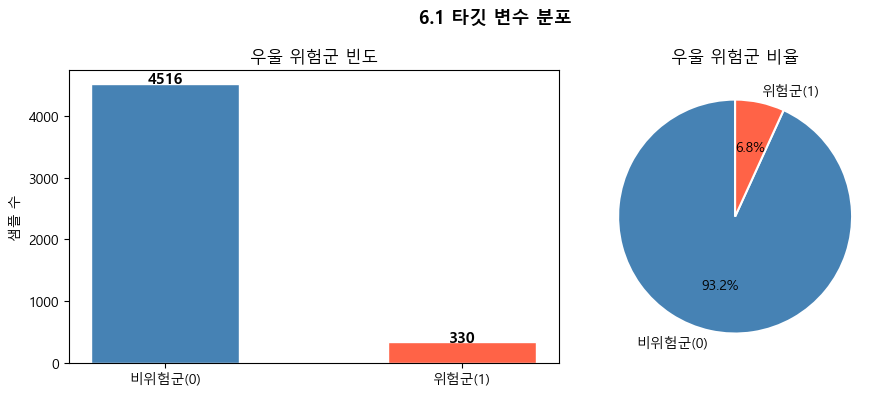

클래스 불균형 비율: 13.7:1  →  ⚠ 불균형 주의 (>5:1)

  6.2 연속형 변수 기술 통계
                   count   mean    std  min   50%    max  skewness  kurtosis
wkdy_sleep_hours  4838.0   6.75   1.29  3.0   7.0   14.0     -0.00      0.65
wknd_sleep_hours  4838.0   7.50   1.61  2.0   8.0   16.0      0.13      0.77
ear_noise_min      553.0  79.98  82.24  1.0  60.0  600.0      2.69     10.77
tinnitus_dist      356.0   3.72   2.60  0.0   3.0   10.0      0.37     -0.28 

Saved figure: figures\02_continuous.png


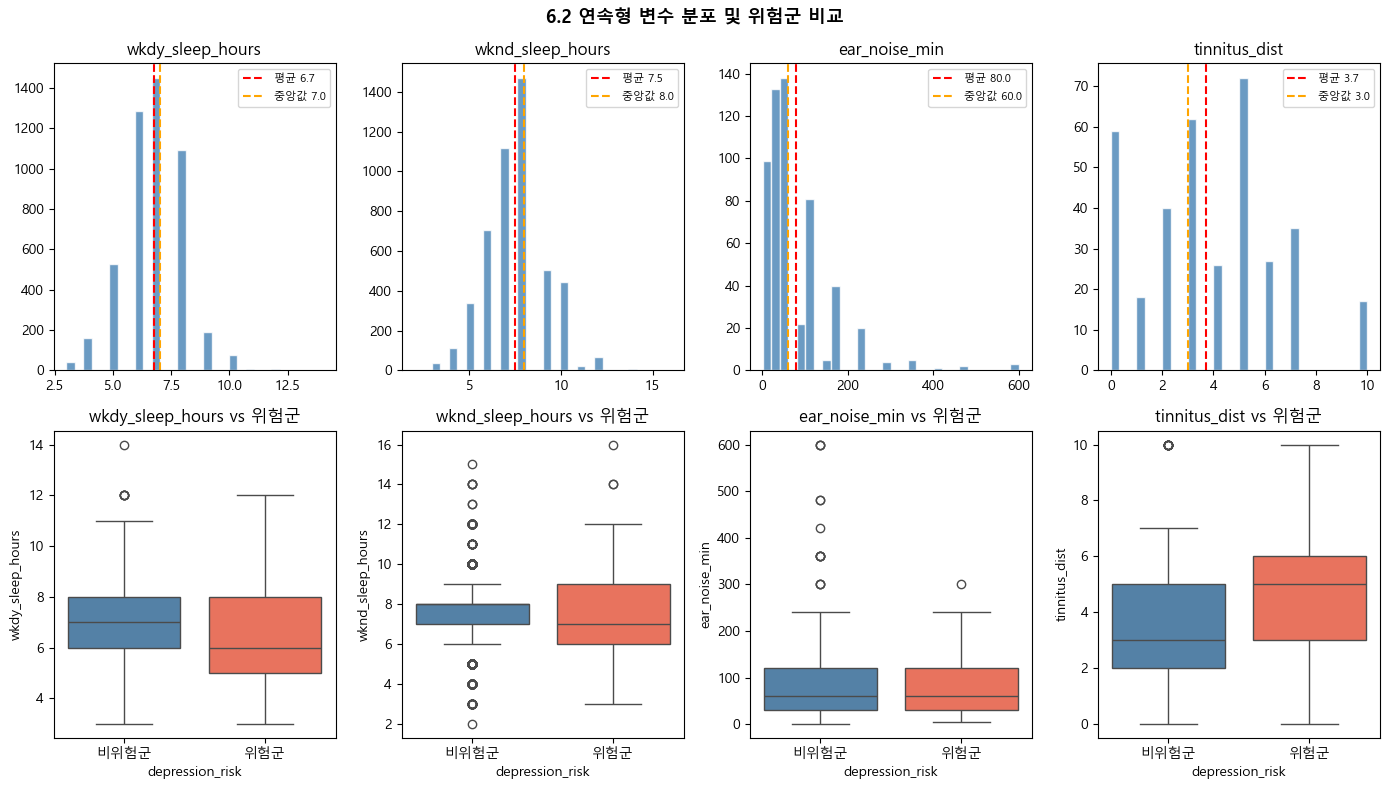

=== Mann-Whitney U 검정 (연속형 vs 위험군) ===
  wkdy_sleep_hours         : 비위험군 6.77 / 위험군 6.41  p=0.0000  ★ 유의
  wknd_sleep_hours         : 비위험군 7.51 / 위험군 7.33  p=0.0254  ★ 유의
  ear_noise_min            : 비위험군 80.00 / 위험군 79.77  p=0.7518  비유의
  tinnitus_dist            : 비위험군 3.61 / 위험군 4.90  p=0.0238  ★ 유의


In [45]:
import seaborn as sns
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
os.makedirs("figures", exist_ok=True)

TARGET    = "depression_risk"
CONT_COLS = ["wkdy_sleep_hours", "wknd_sleep_hours", "ear_noise_min", "tinnitus_dist"]
CAT_COLS  = [c for c in available_features if c not in CONT_COLS]
colors    = ["steelblue", "tomato"]

print("=" * 60)
print(f"  EDA  |  샘플: {len(df_eda)}  |  변수: {len(available_features)}")
print("=" * 60)

# ── 6.1 타깃 변수 분포 ────────────────────────────────────────────
counts    = df_eda[TARGET].value_counts().sort_index()
imbalance = counts[0] / counts[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["비위험군(0)", "위험군(1)"], counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("우울 위험군 빈도")
axes[0].set_ylabel("샘플 수")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 15, str(v), ha="center", fontsize=11, fontweight="bold")
axes[1].pie(counts.values, labels=["비위험군(0)", "위험군(1)"],
            autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("우울 위험군 비율")
plt.suptitle("6.1 타깃 변수 분포", fontsize=13, fontweight="bold")
plt.tight_layout()
save_current_figure("01_target_dist.png", "Target distribution")
plt.show()
print(f"클래스 불균형 비율: {imbalance:.1f}:1  →  {'⚠ 불균형 주의 (>5:1)' if imbalance > 5 else '허용 범위'}\n")

# ── 6.2 연속형 변수 단변량 분석 ──────────────────────────────────
valid_cont = [c for c in CONT_COLS if c in df_eda.columns]
print("=" * 60)
print("  6.2 연속형 변수 기술 통계")
print("=" * 60)
desc = df_eda[valid_cont].describe().T
desc["skewness"] = df_eda[valid_cont].skew()
desc["kurtosis"] = df_eda[valid_cont].kurt()
print(desc[["count", "mean", "std", "min", "50%", "max", "skewness", "kurtosis"]].round(2).to_string(), "\n")

fig, axes = plt.subplots(2, len(valid_cont), figsize=(14, 8))
for i, col in enumerate(valid_cont):
    data = df_eda[col].dropna()
    axes[0][i].hist(data, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[0][i].axvline(data.mean(),   color="red",    linestyle="--", label=f"평균 {data.mean():.1f}")
    axes[0][i].axvline(data.median(), color="orange", linestyle="--", label=f"중앙값 {data.median():.1f}")
    axes[0][i].set_title(col)
    axes[0][i].legend(fontsize=8)
    # palette를 dict 대신 리스트로 전달 (seaborn 최신 버전 호환)
    plot_df = df_eda[[col, TARGET]].dropna().copy()
    plot_df[TARGET] = plot_df[TARGET].astype(str)
    sns.boxplot(data=plot_df, x=TARGET, y=col, ax=axes[1][i],
                order=["0", "1"], palette={"0": "steelblue", "1": "tomato"})
    axes[1][i].set_xticklabels(["비위험군", "위험군"])
    axes[1][i].set_title(f"{col} vs 위험군")
plt.suptitle("6.2 연속형 변수 분포 및 위험군 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
save_current_figure("02_continuous.png", "Continuous feature distributions")
plt.show()

print("=== Mann-Whitney U 검정 (연속형 vs 위험군) ===")
for col in valid_cont:
    g0 = df_eda[df_eda[TARGET] == 0][col].dropna()
    g1 = df_eda[df_eda[TARGET] == 1][col].dropna()
    if len(g0) > 0 and len(g1) > 0:
        _, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        sig = "★ 유의" if p < 0.05 else "비유의"
        print(f"  {col:<25}: 비위험군 {g0.mean():.2f} / 위험군 {g1.mean():.2f}  p={p:.4f}  {sig}")


#### 실행 결과 해석

EDA 결과 우울 위험군과 비위험군의 비율은 약 `13.7:1`로 불균형이 크다. 연속형 변수에서는 위험군의 주중 수면시간이 더 짧은 경향이 나타났고, `wkdy_sleep_hours`, `wknd_sleep_hours`, `tinnitus_dist`는 Mann-Whitney U 검정에서 유의한 차이를 보였다. 따라서 이후 모델링에서는 Accuracy만으로 성능을 해석하기 어렵고, Recall·F2-score 중심 평가가 필요하다.


Saved figure: figures\03_categorical.png


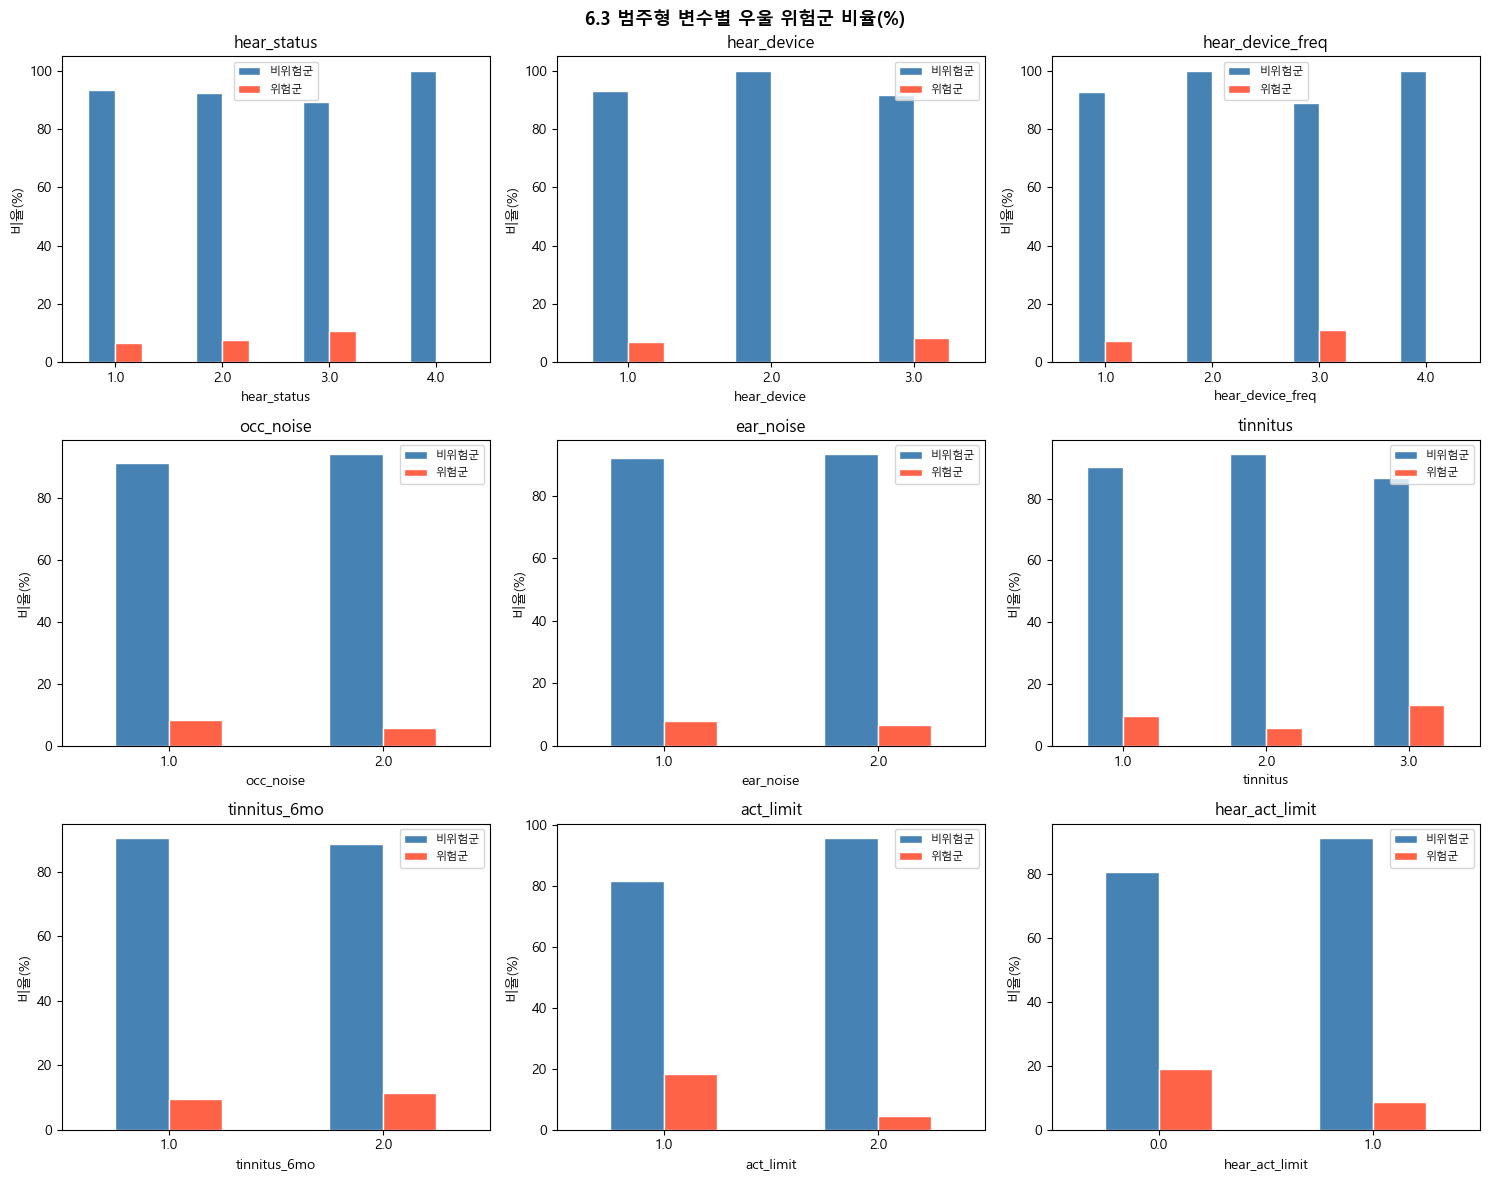

=== 카이제곱 검정 (범주형 vs 위험군) ===
  hear_status              : χ²=  3.96  p=0.2663  비유의
  hear_device              : χ²=  0.34  p=0.8455  비유의
  hear_device_freq         : χ²=  1.19  p=0.7553  비유의
  occ_noise                : χ²=  5.16  p=0.0231  ★ 유의
  ear_noise                : χ²=  0.96  p=0.3281  비유의
  tinnitus                 : χ²= 11.59  p=0.0030  ★ 유의
  tinnitus_6mo             : χ²=  0.07  p=0.7941  비유의
  act_limit                : χ²=208.80  p=0.0000  ★ 유의
  hear_act_limit           : χ²=  3.27  p=0.0706  비유의


In [46]:
# ── 6.3 범주형 변수 분석 + 카이제곱 검정 ────────────────────────
valid_cat = [c for c in CAT_COLS if c in df_eda.columns]
n_cols = 3
n_rows = -(-len(valid_cat) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(valid_cat):
    ct = pd.crosstab(df_eda[col], df_eda[TARGET], normalize="index") * 100
    ct.columns = ["비위험군", "위험군"]
    ct.plot(kind="bar", ax=axes[i], color=colors, rot=0, edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_ylabel("비율(%)")
    axes[i].legend(fontsize=8)
for j in range(len(valid_cat), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("6.3 범주형 변수별 우울 위험군 비율(%)", fontsize=13, fontweight="bold")
plt.tight_layout()
save_current_figure("03_categorical.png", "Categorical feature distributions")
plt.show()

print("=== 카이제곱 검정 (범주형 vs 위험군) ===")
for col in valid_cat:
    ct = pd.crosstab(df_eda[col], df_eda[TARGET])
    if ct.shape[1] < 2:
        continue
    chi2, p, _, _ = stats.chi2_contingency(ct)
    sig = "★ 유의" if p < 0.05 else "비유의"
    print(f"  {col:<25}: χ²={chi2:>6.2f}  p={p:.4f}  {sig}")


#### 실행 결과 해석

범주형 변수와 우울 위험군 간 관계를 카이제곱 검정으로 확인했다. `occ_noise`, `tinnitus`, `act_limit`은 통계적으로 유의한 차이를 보였고, 특히 `act_limit`의 카이제곱 통계량이 크게 나타났다. 다만 이는 단면 설문 자료의 연관성일 뿐 원인으로 해석해서는 안 된다.


Saved figure: figures\04_correlation.png


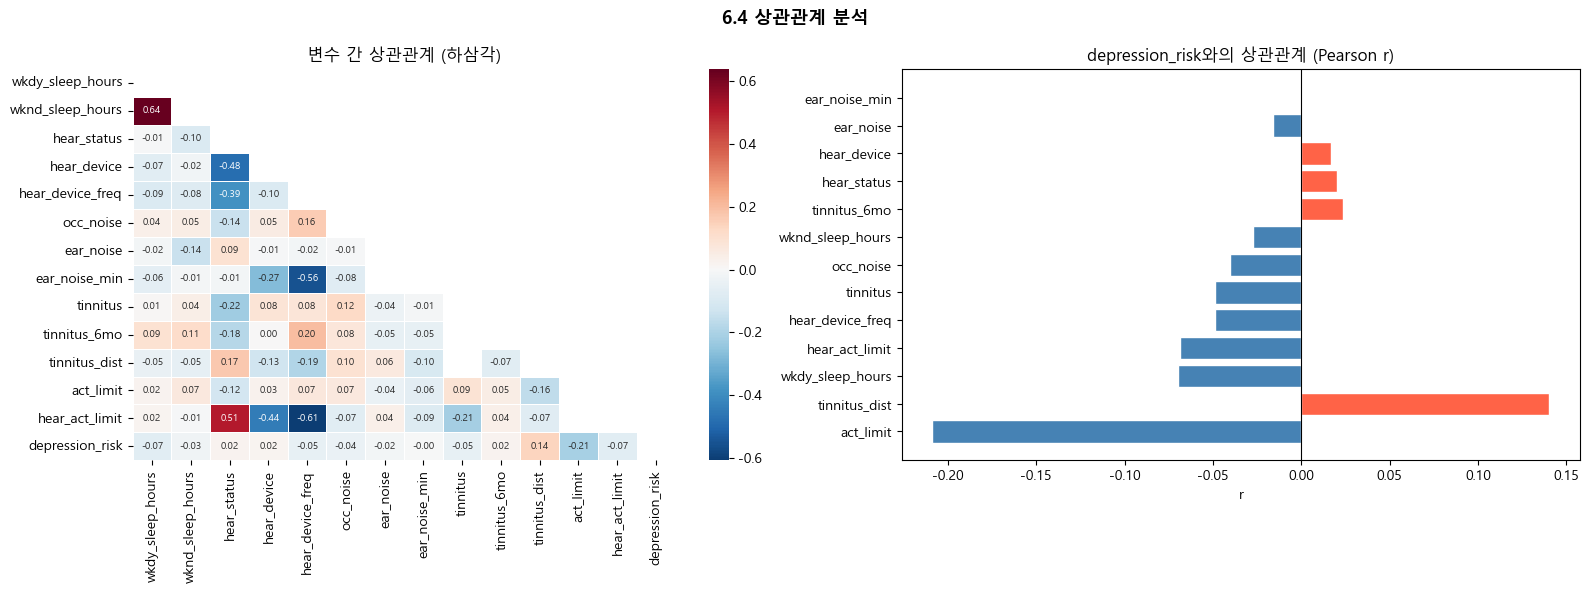

=== 타깃과 상관관계 TOP 5 ===
act_limit          -0.209
tinnitus_dist       0.140
wkdy_sleep_hours   -0.070
hear_act_limit     -0.069
hear_device_freq   -0.049


In [47]:
# ── 6.4 상관관계 분석 ────────────────────────────────────────────
corr_cols = available_features + [TARGET]
corr = df_eda[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[0], linewidths=0.5, annot_kws={"size": 7})
axes[0].set_title("변수 간 상관관계 (하삼각)")

target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
bar_colors  = ["tomato" if v > 0 else "steelblue" for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("depression_risk와의 상관관계 (Pearson r)")
axes[1].set_xlabel("r")
plt.suptitle("6.4 상관관계 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
save_current_figure("04_correlation.png", "Correlation heatmap")
plt.show()

print("=== 타깃과 상관관계 TOP 5 ===")
print(target_corr.head(5).round(3).to_string())


#### 실행 결과 해석

상관분석에서는 `act_limit`, `tinnitus_dist`, `wkdy_sleep_hours` 등이 타깃과 상대적으로 큰 관련성을 보였다. 상관계수의 절댓값은 전반적으로 크지 않으므로 단일 변수만으로 위험군을 설명하기보다는 여러 자기보고 지표를 결합해 선별 가능성을 탐색하는 방향이 적절하다.


  6.5 이상치 탐지 (IQR 1.5 기준, 연속형 변수)
  wkdy_sleep_hours         : 정상 범위 [3.0, 11.0]  →  이상치 8개 (0.2%)
  wknd_sleep_hours         : 정상 범위 [5.5, 9.5]  →  이상치 1034개 (21.3%)
  ear_noise_min            : 정상 범위 [-105.0, 255.0]  →  이상치 15개 (0.3%)
  tinnitus_dist            : 정상 범위 [-2.5, 9.5]  →  이상치 17개 (0.4%)

  6.6 결측치 분석
                  결측 수       결측률
hear_device_freq  4771  0.984523
tinnitus_dist     4490  0.926537
tinnitus_6mo      4450  0.918283
ear_noise_min     4293  0.885885
hear_device       4198  0.866281
hear_act_limit    4012  0.827899
occ_noise         1389  0.286628
tinnitus          1389  0.286628
hear_status        267  0.055097
ear_noise          267  0.055097
wkdy_sleep_hours     8  0.001651
wknd_sleep_hours     8  0.001651
act_limit            3  0.000619 

Saved figure: figures\05_missing.png


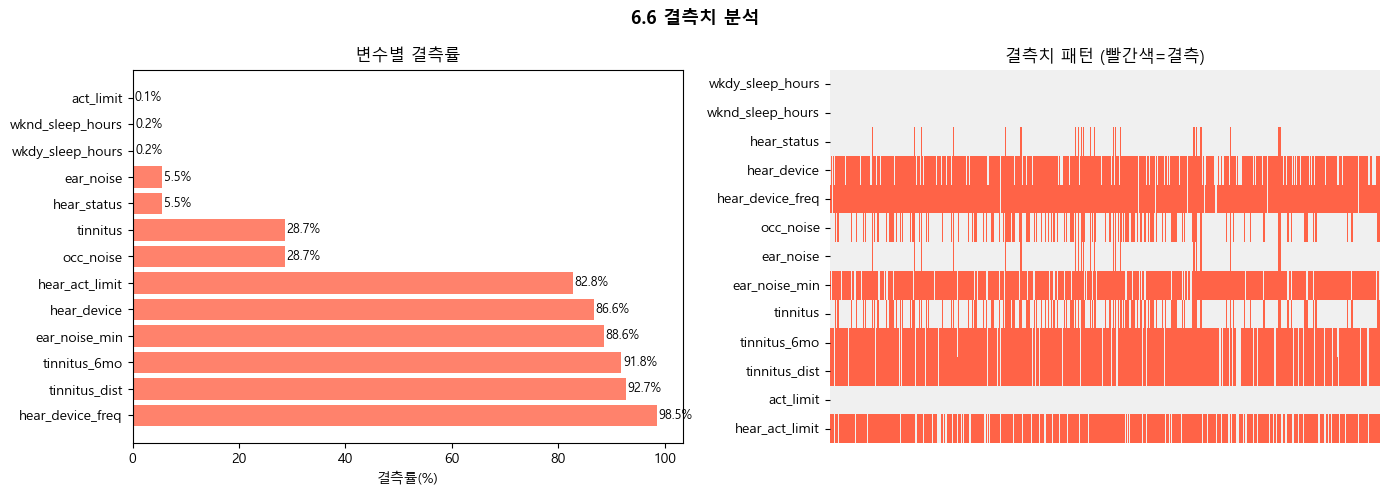

  EDA 요약
1. 클래스 불균형  : 13.7:1  → 모델링 시 stratify / class_weight 적용 필요
2. 수면시간       : 위험군이 더 짧은 경향 (Mann-Whitney 검정 확인)
3. 결측치 최다    : hear_device_freq (98.5%) → 파이프라인 내 imputer로 처리
4. 타깃 상관 1위  : act_limit (r=-0.209)
5. 이상치 최다    : wknd_sleep_hours (21.3%) → 파이프라인 내 처리 또는 클리핑 검토


In [48]:
# ── 6.5 이상치 탐지 (IQR) ────────────────────────────────────────
print("=" * 60)
print("  6.5 이상치 탐지 (IQR 1.5 기준, 연속형 변수)")
print("=" * 60)
outlier_info = {}
for col in valid_cont:
    q1, q3 = df_eda[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_eda[col] < lo) | (df_eda[col] > hi)).sum()
    outlier_info[col] = {"lower": lo, "upper": hi, "n": n_out, "rate": n_out / len(df_eda)}
    print(f"  {col:<25}: 정상 범위 [{lo:.1f}, {hi:.1f}]  →  이상치 {n_out}개 ({n_out/len(df_eda):.1%})")

# ── 6.6 결측치 분석 ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("  6.6 결측치 분석")
print("=" * 60)
missing = df_eda[available_features].isna().mean().sort_values(ascending=False)
miss_df = df_eda[available_features].isna().sum().sort_values(ascending=False).to_frame("결측 수")
miss_df["결측률"] = missing
print(miss_df.to_string(), "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
missing_nz = missing[missing > 0]
if len(missing_nz) > 0:
    axes[0].barh(missing_nz.index, missing_nz.values * 100, color="tomato", alpha=0.8)
    axes[0].set_xlabel("결측률(%)")
    axes[0].set_title("변수별 결측률")
    for i, v in enumerate(missing_nz.values):
        axes[0].text(v * 100 + 0.3, i, f"{v:.1%}", va="center", fontsize=9)
else:
    axes[0].text(0.5, 0.5, "결측치 없음", ha="center", transform=axes[0].transAxes)
sns.heatmap(df_eda[available_features].isna().T, cbar=False,
            cmap=["#f0f0f0", "tomato"], ax=axes[1],
            yticklabels=True, xticklabels=False)
axes[1].set_title("결측치 패턴 (빨간색=결측)")
plt.suptitle("6.6 결측치 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
save_current_figure("05_missing.png", "Missingness summary")
plt.show()

# ── EDA 요약 ────────────────────────────────────────────────────
top_out = max(outlier_info, key=lambda x: outlier_info[x]["rate"]) if outlier_info else "N/A"
print("=" * 60)
print("  EDA 요약")
print("=" * 60)
print(f"1. 클래스 불균형  : {imbalance:.1f}:1  → 모델링 시 stratify / class_weight 적용 필요")
print(f"2. 수면시간       : 위험군이 더 짧은 경향 (Mann-Whitney 검정 확인)")
print(f"3. 결측치 최다    : {missing.index[0]} ({missing.iloc[0]:.1%}) → 파이프라인 내 imputer로 처리")
print(f"4. 타깃 상관 1위  : {target_corr.index[0]} (r={target_corr.iloc[0]:.3f})")
if top_out != "N/A":
    print(f"5. 이상치 최다    : {top_out} ({outlier_info[top_out]['rate']:.1%}) → 파이프라인 내 처리 또는 클리핑 검토")


#### 실행 결과 해석

이상치와 결측률을 함께 확인했다. 주말 수면시간은 IQR 기준 이상치 비율이 높지만, 이는 생활 패턴 차이를 반영할 수 있으므로 무조건 제거하기보다 파생변수와 전처리 파이프라인으로 다루는 것이 안전하다. 결측률이 높은 청각·이명 관련 변수는 설문 구조상 비해당 응답이 많을 가능성이 있어 결측 자체도 정보로 활용할 수 있다.


---

# 8. 모델링 데이터 구성

PHQ 문항과 PHQ 총점은 타깃 생성에 사용된 변수이므로 모델 입력 변수에서는 제외한다. 식별자인 `id` 역시 모델 입력에 포함하지 않는다.

본 모델은 PHQ-9 또는 PHQ8을 대체하기 위한 도구가 아니다. PHQ-9를 직접 시행할 수 있는 상황에서는 PHQ-9가 가장 직접적인 선별도구이다. 본 연구의 의의는 PHQ8 기준 위험군을 기준으로 수면시간, 청각 문제, 소음 노출과 같은 비정신건강 설문 지표들이 위험군 선별에 어느 정도 정보를 제공하는지 탐색했다는 데 있다.


In [49]:
# EDA 단계에서 정의한 available_features를 사용한다.
model_cols = [col for col in ["id"] + available_features + ["depression_risk"] if col in df_selected.columns]

df_model = df_selected[model_cols].copy()
df_model = df_model.dropna(subset=["depression_risk"])
df_model["depression_risk"] = df_model["depression_risk"].astype(int)

# ============================================================
# 7-1. 코드북 기반 의미 중심 전처리
# ============================================================

# 1) 청각보조기기 사용 여부
# T_Q_HR_1: 1=보청기, 2=인공와우, 3=사용하지 않음
df_model["hear_device_use"] = np.select(
    [
        df_model["hear_device"].isin([1, 2]),
        df_model["hear_device"].eq(3)
    ],
    [1, 0],
    default=np.nan
)

# 청각보조기기 사용 빈도
# 사용하지 않는 사람은 '빈도 없음'이므로 0으로 처리
# 사용하는 사람인데 빈도 응답이 없으면 결측으로 유지
df_model["hear_device_freq_ord"] = df_model["hear_device_freq"].copy()
df_model.loc[df_model["hear_device_use"].eq(0), "hear_device_freq_ord"] = 0

# 실제 사용군 중 빈도 결측 여부
df_model["hear_device_freq_unknown"] = (
    df_model["hear_device_use"].eq(1) & df_model["hear_device_freq"].isna()
).astype(int)

# 2) 직업적 소음 노출
df_model["occ_noise_yes"] = df_model["occ_noise"].replace({
    1: 1,
    2: 0
})

# 3) 시끄러운 장소에서 이어폰 사용 여부
df_model["ear_noise_use"] = df_model["ear_noise"].replace({
    1: 1,
    2: 0
})

# 이어폰 사용 경험이 없는 사람은 사용시간 0분으로 처리
df_model["ear_noise_min_clean"] = df_model["ear_noise_min"].copy()
df_model.loc[df_model["ear_noise_use"].eq(0), "ear_noise_min_clean"] = 0

# 이어폰 사용한다고 했는데 사용시간이 결측인 경우만 결측 플래그
df_model["ear_noise_min_missing"] = (
    df_model["ear_noise_use"].eq(1) & df_model["ear_noise_min"].isna()
).astype(int)

# 4) 이명 여부
df_model["tinnitus_use"] = df_model["tinnitus"].replace({
    1: 1,
    2: 0
})

# 이명이 없는 사람은 6개월 이상 지속 여부도 0으로 처리
df_model["tinnitus_6mo_yes"] = df_model["tinnitus_6mo"].replace({
    1: 1,
    2: 0
})
df_model.loc[df_model["tinnitus_use"].eq(0), "tinnitus_6mo_yes"] = 0

# 이명 괴로움 정도
# 이명이 없는 사람은 괴로움 정도 0으로 처리
df_model["tinnitus_dist_score"] = df_model["tinnitus_dist"].copy()
df_model.loc[df_model["tinnitus_use"].eq(0), "tinnitus_dist_score"] = 0

# 5) 활동제한 여부
# LQ4_00은 1=예, 2=아니오 구조로 보고 이진화
df_model["act_limit_yes"] = df_model["act_limit"].replace({
    1: 1,
    2: 0
})

# 청각 문제로 인한 활동제한
df_model["hear_act_limit_yes"] = df_model["hear_act_limit"].replace({
    1: 1,
    2: 0
})

# 전체 활동제한이 없는 사람은 청각 문제로 인한 활동제한도 0으로 처리
df_model.loc[df_model["act_limit_yes"].eq(0), "hear_act_limit_yes"] = 0

# 6) 수면시간 클리핑
# 0~24시간 외 값은 이미 결측 처리했고, 모델링에서는 극단값 완화
for col in ["wkdy_sleep_hours", "wknd_sleep_hours"]:
    df_model[col] = df_model[col].clip(lower=2, upper=16)

print("모델링용 데이터 크기:", df_model.shape)
df_model.head()


모델링용 데이터 크기: (4846, 27)


,id,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device,hear_device_freq,occ_noise,ear_noise,ear_noise_min,tinnitus,tinnitus_6mo,tinnitus_dist,act_limit,hear_act_limit,depression_risk,hear_device_use,hear_device_freq_ord,hear_device_freq_unknown,occ_noise_yes,ear_noise_use,ear_noise_min_clean,ear_noise_min_missing,tinnitus_use,tinnitus_6mo_yes,tinnitus_dist_score,act_limit_yes,hear_act_limit_yes
0,YA01220302,8.0,10.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,1.0,0.0,0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0
1,YA01220303,7.0,7.0,1.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,2.0,NaN,0,NaN,NaN,0,NaN,0.0,0.0,0,NaN,NaN,NaN,0.0,0.0
2,YA01220304,6.0,8.0,1.0,NaN,NaN,NaN,1.0,20.0,NaN,NaN,NaN,2.0,NaN,1,NaN,NaN,0,NaN,1.0,20.0,0,NaN,NaN,NaN,0.0,0.0
3,YA01236501,9.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0
4,YA01236502,7.0,9.0,1.0,NaN,NaN,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0


#### 실행 결과 해석

모델링용 데이터는 `4846 × 27` 형태로 정리되었다. PHQ 문항과 PHQ 총점은 타깃 생성에 사용된 정보이므로 입력 변수에서 제외해야 하며, 이 셀은 이후 feature engineering과 train/validation/test split에 사용할 분석용 테이블을 구성하는 단계이다.


## 8.1 피처 엔지니어링

EDA에서 확인한 수면시간 분포와 위험군 차이를 바탕으로 수면 관련 파생 피처를 추가한다.

- `sleep_short` : 주중 수면시간 6시간 미만 이진 지시자 — 수면 부족 여부
- `sleep_long` : 주중 수면시간 9시간 이상 이진 지시자 — 장시간 수면 여부
- `sleep_diff` : 주말 수면시간 − 주중 수면시간 — 주중/주말 수면 패턴 변화
- `sleep_catchup_large` : 주말 수면시간이 주중보다 2시간 이상 긴 경우 — 수면 보충 또는 불규칙성 지표


In [50]:
# ============================================================
# 7-2. 수면 관련 파생변수
# ============================================================

df_model["sleep_short"] = (df_model["wkdy_sleep_hours"] < 6).astype(int)
df_model["sleep_long"] = (df_model["wkdy_sleep_hours"] >= 9).astype(int)

# 주말-주중 수면시간 차이
df_model["sleep_diff"] = df_model["wknd_sleep_hours"] - df_model["wkdy_sleep_hours"]

# 주말에 2시간 이상 더 자는 경우: 수면 보충/불규칙성 지표
df_model["sleep_catchup_large"] = (df_model["sleep_diff"] >= 2).astype(int)

print("추가된 피처: sleep_short, sleep_long, sleep_diff, sleep_catchup_large")
df_model[[
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "sleep_short",
    "sleep_long",
    "sleep_diff",
    "sleep_catchup_large"
]].describe().round(2)


추가된 피처: sleep_short, sleep_long, sleep_diff, sleep_catchup_large


,wkdy_sleep_hours,wknd_sleep_hours,sleep_short,sleep_long,sleep_diff,sleep_catchup_large
count,4838.00,4838.00,4846.00,4846.00,4838.00,4846.00
mean,6.75,7.50,0.15,0.06,0.75,0.23
std,1.29,1.61,0.36,0.23,1.27,0.42
min,3.00,2.00,0.00,0.00,-6.00,0.00
25%,6.00,7.00,0.00,0.00,0.00,0.00
50%,7.00,8.00,0.00,0.00,0.00,0.00
75%,8.00,8.00,0.00,0.00,1.00,0.00
max,14.00,16.00,1.00,1.00,9.00,1.00


#### 실행 결과 해석

수면시간 기반 파생변수 `sleep_short`, `sleep_long`, `sleep_diff`, `sleep_catchup_large`가 추가되었다. 평균적으로 주말 수면시간이 주중보다 길고, `sleep_catchup_large` 비율도 일부 존재한다. 이는 단순 수면시간뿐 아니라 수면 패턴의 불규칙성 또는 보충 수면 가능성을 모델에 반영하기 위한 처리이다.


---

# 9. Train/Validation/Test Split 및 전처리 파이프라인

## 클래스 불균형 처리 전략

EDA 결과 비위험군 : 위험군 = **13.7 : 1**의 심각한 클래스 불균형이 확인됐다.
다음 두 가지 방법을 적용한다.

| 방법 | 적용 위치 | 효과 |
|------|-----------|------|
| `stratify=y` | `train_test_split` | 분할 후에도 클래스 비율 유지 |
| `class_weight='balanced'` | 분류 모델 초기화 | 소수 클래스(위험군)에 역비율 가중치 부여 |

결측치 대체, 인코딩, 스케일링은 train/validation/test split 이후 파이프라인 내부에서 수행한다 (데이터 누수 방지).


## 9.1 PHQ 타깃 누수 점검 및 train/validation/test 분할

PHQ8 점수를 타깃으로 사용하므로, PHQ 문항 및 PHQ 파생 점수는 모델 입력 변수에서 제외한다. 특히 수면시간이 입력 변수로 들어가므로 PHQ-9의 수면 문항인 `phq_3`은 타깃 점수에서도 제외했고, PHQ8 기준 우울 위험군(`phq8_score >= 7`)을 사용한다.

모든 모델은 동일한 stratified train/validation/test split을 사용한다. 모델 학습은 train set에서 수행하고, threshold 선택은 validation set에서만 수행한다. test set은 validation에서 선택된 threshold를 고정한 뒤 최종 성능 평가에만 사용한다.

In [51]:
# Remove target/leakage columns and raw source columns not used as model inputs.
drop_from_X = [
    c for c in [
        "id", "depression_risk", "hear_device", "hear_device_freq",
        "occ_noise", "ear_noise", "ear_noise_min", "tinnitus",
        "tinnitus_6mo", "tinnitus_dist", "act_limit", "hear_act_limit"
    ]
    if c in df_model.columns
]

X = df_model.drop(columns=drop_from_X)
y = df_model["depression_risk"]

leakage_cols = [
    "phq_1", "phq_2", "phq_3", "phq_4", "phq_5",
    "phq_6", "phq_7", "phq_8", "phq_9",
    "phq_score", "phq8_score", "depression_risk"
]
leaked = [c for c in leakage_cols if c in X.columns]

if leaked:
    raise ValueError(f"PHQ target leakage columns remain in X: {leaked}")
else:
    print("PHQ target leakage columns: none")

if y.nunique() < 2:
    raise ValueError("Only one target class is present. Check depression_risk creation.")

# 64% train, 16% validation, 20% test.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_train_val
)

print("X_train:", X_train.shape, "  X_val:", X_val.shape, "  X_test:", X_test.shape)
print("Train/validation/test split: 64% / 16% / 20%")
print("\nTrain target ratio")
print(y_train.value_counts(normalize=True).sort_index())
print("\nValidation target ratio")
print(y_val.value_counts(normalize=True).sort_index())
print("\nTest target ratio")
print(y_test.value_counts(normalize=True).sort_index())


PHQ target leakage columns: none
X_train: (3100, 19)   X_val: (776, 19)   X_test: (970, 19)
Train/validation/test split: 64% / 16% / 20%

Train target ratio
depression_risk
0    0.931935
1    0.068065
Name: proportion, dtype: float64

Validation target ratio
depression_risk
0    0.931701
1    0.068299
Name: proportion, dtype: float64

Test target ratio
depression_risk
0    0.931959
1    0.068041
Name: proportion, dtype: float64


#### 실행 결과 해석

train/validation/test split 결과 학습 데이터는 3,100명, validation 데이터는 776명, 테스트 데이터는 970명으로 나뉘었다. 세 데이터셋 모두 우울 위험군 비율이 약 6.8%로 거의 동일하게 유지되었으므로 `stratify=y`가 정상적으로 작동했다. 모델은 train set에서 학습하고 threshold는 validation set에서만 선택하며, test set은 선택된 threshold를 고정한 최종 평가에만 사용한다.


In [52]:
# 수치형/이진형 변수
numeric_features = [c for c in [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "sleep_diff",
    "sleep_short",
    "sleep_long",
    "sleep_catchup_large",

    "hear_device_use",
    "hear_device_freq_ord",
    "hear_device_freq_unknown",

    "occ_noise_yes",
    "ear_noise_use",
    "ear_noise_min_clean",
    "ear_noise_min_missing",

    "tinnitus_use",
    "tinnitus_6mo_yes",
    "tinnitus_dist_score",

    "act_limit_yes",
    "hear_act_limit_yes",
] if c in X.columns]

# 남은 변수 중 범주형으로 처리할 변수
# hear_status는 본인 청력 불편 정도를 나타내는 순서형 범주 변수이다. 여기서는 범주별 효과를 독립적으로 반영하기 위해 one-hot encoding으로 처리한다.
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("수치형 변수:", numeric_features)
print("범주형 변수:", categorical_features)


수치형 변수: ['wkdy_sleep_hours', 'wknd_sleep_hours', 'sleep_diff', 'sleep_short', 'sleep_long', 'sleep_catchup_large', 'hear_device_use', 'hear_device_freq_ord', 'hear_device_freq_unknown', 'occ_noise_yes', 'ear_noise_use', 'ear_noise_min_clean', 'ear_noise_min_missing', 'tinnitus_use', 'tinnitus_6mo_yes', 'tinnitus_dist_score', 'act_limit_yes', 'hear_act_limit_yes']
범주형 변수: ['hear_status']


#### 실행 결과 해석

전처리 파이프라인에 들어갈 수치형 변수와 범주형 변수가 분리되었다. 대부분의 변수는 이진화·순서화·연속형 형태로 정리되어 수치형으로 처리되고, `hear_status`는 범주형으로 one-hot encoding된다. 이 구분은 결측치 대체, 스케일링, 인코딩을 train/validation/test 분리 이후에 적용하기 위한 준비 단계이다.


---

# 10. 모델 학습

동일한 전처리 파이프라인을 사용하여 여러 분류 모델의 성능을 비교한다.


### 패키지 설치 안내

`imbalanced-learn`, `torch`, `shap`이 설치되어 있으면 전체 기능을 사용할 수 있다.  
설치되어 있지 않은 환경에서도 기본 머신러닝 모델은 실행되도록 예외 처리를 적용한다.

딥러닝 모델과 SHAP 분석을 사용하려면 아래 명령을 별도 셀에서 한 번만 실행한다.

```python
%pip install imbalanced-learn torch shap
```


In [53]:
# !pip install imbalanced-learn torch shap

#### 실행 결과 해석

이 셀은 `imbalanced-learn`, `torch`, `shap` 설치 안내용 셀이다. 기본 머신러닝 모델만 실행할 경우 필수는 아니지만, UnderSampling 모델, Focal MLP, SHAP 해석까지 모두 실행하려면 해당 패키지가 필요하다.


## 10.1 Focal MLP 딥러닝 모델 정의

Focal MLP는 선택적으로 실행되는 보조 딥러닝 모델이다. 이 estimator 내부에서는 별도의 validation split이나 threshold 선택을 하지 않고, 공통 평가 루프에서 다른 모델들과 동일하게 validation set 기준 threshold를 선택한다.

In [54]:
# Optional imports for the PyTorch-based Focal MLP.
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.base import BaseEstimator, ClassifierMixin
    import scipy.sparse
    FOCAL_MLP_AVAILABLE = True
except ImportError as e:
    FOCAL_MLP_AVAILABLE = False
    print("PyTorch/scipy is unavailable, so Focal MLP will be skipped.")
    print("Install with `%pip install torch scipy` if this model is needed.")
    print("ImportError:", e)

if FOCAL_MLP_AVAILABLE:
    class _FocalLoss(nn.Module):
        """Focal Loss with moderate pos_weight (sqrt of imbalance ratio)."""
        def __init__(self, gamma=2.0, pos_weight=None):
            super().__init__()
            self.gamma = gamma
            self.pos_weight = pos_weight

        def forward(self, logits, targets):
            bce = nn.functional.binary_cross_entropy_with_logits(
                logits, targets, pos_weight=self.pos_weight, reduction="none"
            )
            probs = torch.sigmoid(logits)
            p_t = probs * targets + (1 - probs) * (1 - targets)
            return ((1 - p_t) ** self.gamma * bce).mean()

    class _ResBlock(nn.Module):
        def __init__(self, in_dim, out_dim, dropout):
            super().__init__()
            self.block = nn.Sequential(
                nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU(), nn.Dropout(dropout)
            )
            self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

        def forward(self, x):
            return self.block(x) + self.skip(x)

    class _MLPNet(nn.Module):
        def __init__(self, input_dim, hidden_dims, dropout):
            super().__init__()
            dims = [input_dim] + list(hidden_dims)
            self.blocks = nn.Sequential(*[_ResBlock(dims[i], dims[i + 1], dropout) for i in range(len(dims) - 1)])
            self.head = nn.Linear(dims[-1], 1)

        def forward(self, x):
            return self.head(self.blocks(x)).squeeze(-1)

    class FocalMLP(ClassifierMixin, BaseEstimator):
        """ResNet-style MLP with Focal Loss.

        Threshold is not selected inside this estimator. The common evaluation loop
        selects every model's threshold on the shared validation set.
        """
        def __init__(self, hidden_dims=(128, 64, 32), dropout=0.3, gamma=2.0,
                     lr=1e-3, weight_decay=1e-4, epochs=150, batch_size=256,
                     random_state=42, verbose=True):
            self.hidden_dims = hidden_dims
            self.dropout = dropout
            self.gamma = gamma
            self.lr = lr
            self.weight_decay = weight_decay
            self.epochs = epochs
            self.batch_size = batch_size
            self.random_state = random_state
            self.verbose = verbose

        def _to_dense(self, X):
            if scipy.sparse.issparse(X):
                return np.array(X.todense(), dtype=np.float32)
            return np.array(X, dtype=np.float32)

        def fit(self, X, y):
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

            X = self._to_dense(X)
            y = np.array(y, dtype=np.float32)
            self.classes_ = np.array([0, 1])
            n_pos = y.sum()
            n_neg = len(y) - n_pos

            if n_pos == 0:
                raise ValueError("FocalMLP requires at least one positive sample.")

            pos_weight = torch.tensor([float(np.sqrt(n_neg / n_pos))], dtype=torch.float32)
            self.net_ = _MLPNet(X.shape[1], self.hidden_dims, self.dropout)
            criterion = _FocalLoss(gamma=self.gamma, pos_weight=pos_weight)
            optimizer = optim.AdamW(self.net_.parameters(), lr=self.lr, weight_decay=self.weight_decay)

            dataset = TensorDataset(torch.tensor(X), torch.tensor(y))
            loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

            self.net_.train()
            for epoch in range(self.epochs):
                losses = []
                for xb, yb in loader:
                    optimizer.zero_grad()
                    logits = self.net_(xb)
                    loss = criterion(logits, yb)
                    loss.backward()
                    optimizer.step()
                    losses.append(loss.item())

                if self.verbose and (epoch + 1) % 50 == 0:
                    print(f"epoch {epoch + 1:03d} | train loss={np.mean(losses):.4f}")

            self.threshold_ = 0.5
            return self

        def predict_proba(self, X):
            X = self._to_dense(X)
            self.net_.eval()
            with torch.no_grad():
                logits = self.net_(torch.tensor(X))
                probs = torch.sigmoid(logits).numpy()
            return np.vstack([1 - probs, probs]).T

        def decision_function(self, X):
            return self.predict_proba(X)[:, 1]

        def predict(self, X):
            return (self.predict_proba(X)[:, 1] >= self.threshold_).astype(int)


## 10.2 머신러닝/딥러닝 모델 학습

학습 대상에는 Logistic Regression, Random Forest, Hist Gradient Boosting, 선택적 UnderSampling 모델, 선택적 Focal MLP가 포함된다. 모든 모델은 동일한 train set으로만 학습하고, threshold 선택은 다음 평가 섹션에서 validation set 기준으로 공통 수행한다.

In [55]:
# Optional imbalanced-learn models.
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_AVAILABLE = True
except ImportError as e:
    IMBLEARN_AVAILABLE = False
    print("imbalanced-learn is unavailable, so undersampling models will be skipped.")
    print("Install with `%pip install imbalanced-learn` if these models are needed.")
    print("ImportError:", e)

import inspect
def make_hist_gradient_boosting(random_state=RANDOM_STATE):
    """Create HistGradientBoostingClassifier with class_weight when supported."""
    params = {"random_state": random_state}
    if "class_weight" in inspect.signature(HistGradientBoostingClassifier).parameters:
        params["class_weight"] = "balanced"
    return HistGradientBoostingClassifier(**params)

SCREENING_TARGET_RECALL = 0.80

pipelines = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", make_hist_gradient_boosting()),
    ]),
}

if IMBLEARN_AVAILABLE:
    pipelines["Logistic Regression + UnderSampling"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipelines["Random Forest + UnderSampling"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("under", RandomUnderSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ])

if globals().get("FOCAL_MLP_AVAILABLE", False):
    pipelines["Focal MLP"] = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", FocalMLP(gamma=2.0, random_state=RANDOM_STATE)),
    ])

print("Models to train")
for name in pipelines:
    print("-", name)

for name, pipe in pipelines.items():
    print(f"\n[{name}] training start")
    pipe.fit(X_train, y_train)
    print(f"[{name}] training done")


Models to train
- Logistic Regression
- Random Forest
- Hist Gradient Boosting
- Logistic Regression + UnderSampling
- Random Forest + UnderSampling
- Focal MLP

[Logistic Regression] training start
[Logistic Regression] training done

[Random Forest] training start
[Random Forest] training done

[Hist Gradient Boosting] training start
[Hist Gradient Boosting] training done

[Logistic Regression + UnderSampling] training start
[Logistic Regression + UnderSampling] training done

[Random Forest + UnderSampling] training start
[Random Forest + UnderSampling] training done

[Focal MLP] training start
epoch 050 | train loss=0.1331
epoch 100 | train loss=0.1308
epoch 150 | train loss=0.1237
[Focal MLP] training done


#### 실행 결과 해석

학습 대상 모델은 Logistic Regression, Random Forest, Hist Gradient Boosting, UnderSampling 기반 모델 2종, Focal MLP까지 총 6개로 구성되었다. 모든 모델이 train set으로 학습 완료되었고, Focal MLP도 다른 모델과 동일하게 공통 평가 루프에서 validation set 기준 threshold를 선택한다. 따라서 이후 평가는 validation에서 선택한 threshold를 고정한 뒤 test set에서 최종 비교하는 구조로 진행된다.


---

# 11. 성능 평가 및 최종 모델 선택

본 프로젝트의 목적은 우울증 확정 진단이 아니라 PHQ8 기준 우울 위험군 선별 가능성을 탐색하는 것이다. 모델 성능은 Accuracy 중심으로 해석하지 않는다. 우울 위험군은 소수 클래스이므로, 실제 위험군을 놓치는 False Negative를 줄이는 것이 중요하다. 따라서 Recall, F2-score, PR-AUC, confusion matrix를 함께 해석한다.



1. **F2-score 최상위 모델**: 모델별 validation F2-score 최적 threshold를 선택한 뒤, validation F2-score가 가장 높은 모델
2. **조기 선별 모델**: validation Recall이 0.80 이상인 모델-threshold 조합 중 F2-score가 가장 높은 모델

첫 번째 모델은 Recall과 Precision의 균형을 비교하기 위한 최종 성능 기준이며, 두 번째 모델은 우울 위험군을 놓치지 않는 조기 선별 목적에 맞춘 운영 기준이다.


Recall 0.80 이상 기준의 조기 선별 모델은 위험군을 더 많이 포착하는 대신 False Positive가 증가할 수 있다. 이는 모델의 한계라기보다 1차 선별 상황에서 발생하는 trade-off로 해석한다. 따라서 본 모델은 단독 판단 도구가 아니라, 추가 평가가 필요한 대상을 넓게 선별하는 보조적 1차 필터로 해석해야 한다.


### F2-score

F2 score는 Recall에 Precision보다 더 큰 가중치를 두는 F-beta score이다. 위험군을 놓치는 비용이 더 크다고 보는 선별 문제에서, F2-score는 Precision도 함께 보되 Recall을 더 중시하는 균형 지표로 사용할 수 있다.

$$
F_2 = \frac{(1 + 2^2) \cdot \text{Precision} \cdot \text{Recall}}
{2^2 \cdot \text{Precision} + \text{Recall}}
$$

즉,

$$
F_2 = \frac{5 \cdot \text{Precision} \cdot \text{Recall}}
{4 \cdot \text{Precision} + \text{Recall}}
$$


### PR-AUC

PR-AUC는 Precision-Recall Curve 아래 면적을 의미하며, 모델이 양성 클래스(`depression_risk = 1`)를 얼마나 잘 찾아내는지 평가하는 지표이다.

Precision-Recall Curve는 threshold를 변화시키면서 Recall과 Precision의 변화를 나타낸다.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

PR-AUC는 특히 양성 클래스가 적은 불균형 데이터에서 유용하다.  
본 프로젝트처럼 우울 위험군이 비위험군보다 적은 경우, ROC-AUC만 보면 모델 성능이 실제보다 좋아 보일 수 있다. 따라서 PHQ8 기준 우울 위험군 선별에서는 ROC-AUC와 함께 PR-AUC를 확인하는 것이 중요하다.

PR-AUC 값이 클수록 모델이 우울 위험군을 더 안정적으로 탐지한다고 해석할 수 있다.

모델 성능은 Accuracy 중심으로 해석하지 않는다. 우울 위험군은 소수 클래스이므로, 실제 위험군을 놓치는 False Negative를 줄이는 것이 중요하다. 따라서 Recall, F2-score, PR-AUC, confusion matrix를 함께 해석한다.


## 11.1 공통 평가 함수 및 기본 threshold validation 점검

이 섹션부터는 test set을 threshold 탐색에 사용하지 않는다. 먼저 모든 모델에 공통으로 적용할 score 추출 함수와 metric 계산 함수를 정의하고, 기본 threshold 0.5에서의 validation 성능만 참고용으로 확인한다.

`Pred_Pos`는 모델이 우울 위험군(1)으로 선별한 전체 인원수(TP+FP), `Pred_Pos_Rate`는 전체 대상자 중 우울 위험군으로 선별한 비율이다.

In [56]:
from math import ceil
from matplotlib.patches import Rectangle
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, average_precision_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


def get_positive_score(pipe, X_data):
    """Return a positive-class score for ROC-AUC, PR-AUC, and threshold evaluation."""
    model = pipe.named_steps["model"]

    if hasattr(model, "predict_proba"):
        proba = pipe.predict_proba(X_data)
        if getattr(proba, "ndim", 1) == 2 and proba.shape[1] > 1:
            return proba[:, 1]
        return np.asarray(proba).ravel()

    if hasattr(model, "decision_function"):
        return pipe.decision_function(X_data)

    return pipe.predict(X_data)


def predict_with_threshold(pipe, X_data, threshold):
    scores = get_positive_score(pipe, X_data)
    return (scores >= threshold).astype(int), scores


def metric_row(y_true, y_score, threshold, model_name=None):
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    try:
        roc_auc = roc_auc_score(y_true, y_score)
    except ValueError:
        roc_auc = np.nan

    try:
        pr_auc = average_precision_score(y_true, y_score)
    except ValueError:
        pr_auc = np.nan

    row = {
        "threshold": round(float(threshold), 2),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "TP": int(tp),
        "FN": int(fn),
        "FP": int(fp),
        "TN": int(tn),
        "Pred_Pos": int(y_pred.sum()),
        "Pred_Pos_Rate": float(y_pred.mean()),
    }
    if model_name is not None:
        row = {"model": model_name, **row}
    return row


default_validation_rows = []
for name, pipe in pipelines.items():
    val_score = get_positive_score(pipe, X_val)
    default_validation_rows.append(metric_row(y_val, val_score, 0.5, model_name=name))

default_validation_df = pd.DataFrame(default_validation_rows).sort_values(
    ["F2", "Recall", "PR-AUC", "Precision", "FN"],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

default_validation_df.to_csv(
    os.path.join(OUTPUT_DIR, "default_threshold_validation_results.csv"),
    index=False,
    encoding="utf-8-sig",
)

print("=== Default threshold 0.5 validation performance ===")
print("This table is for validation-only diagnostics, not final test selection.")
display(default_validation_df)


=== Default threshold 0.5 validation performance ===
This table is for validation-only diagnostics, not final test selection.


,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate
0,Logistic Regression,0.5,0.683290,0.232218,0.244444,0.384615,0.152074,0.622642,0.737113,0.745505,33,20,184,539,217,0.279639
1,Logistic Regression + UnderSampling,0.5,0.709413,0.243663,0.233216,0.373303,0.143478,0.622642,0.720361,0.727524,33,20,197,526,230,0.296392
2,Random Forest + UnderSampling,0.5,0.679115,0.176540,0.226804,0.366667,0.138655,0.622642,0.710052,0.716459,33,20,205,518,238,0.306701
3,Hist Gradient Boosting,0.5,0.622067,0.188404,0.215247,0.314136,0.141176,0.452830,0.774485,0.798064,24,29,146,577,170,0.219072
4,Random Forest,0.5,0.583483,0.129195,0.165680,0.213415,0.120690,0.264151,0.818299,0.858921,14,39,102,621,116,0.149485
5,Focal MLP,0.5,0.662465,0.170324,0.190476,0.164609,0.258065,0.150943,0.912371,0.968188,8,45,23,700,31,0.039948


#### 실행 결과 해석

기본 threshold 기준 성능 비교에서는 Logistic Regression이 F2-score와 PR-AUC 모두 가장 높게 나타났다. 하지만 우울 위험군 비율이 낮기 때문에 Accuracy가 높은 모델이 반드시 좋은 선별 모델은 아니다. 기본 threshold 결과는 참고용이며, 실제 조기 선별 목적에는 threshold 조정을 통해 Recall과 False Negative를 함께 확인해야 한다.


## 11.2 validation 기반 threshold 선택 및 test 최종 평가

기본 threshold `0.5`만 사용하면 모델별 확률 보정 정도나 decision score 범위에 따라 비교가 불공정할 수 있다. 따라서 모든 모델에 대해 동일한 threshold grid를 validation set에서 탐색한다.

최종 선택은 validation 성능만 보고 두 가지 기준으로 나누어 수행한다.

- **F2-score 최상위 모델**: 모델별 validation F2-score 최적 threshold를 선택한 뒤, validation F2-score가 가장 높은 모델
- **조기 선별 모델**: validation Recall이 0.80 이상인 후보 중 F2-score가 가장 높은 모델. 해당 후보가 없으면 validation Recall이 가장 높은 조합을 fallback으로 사용

선택된 threshold와 모델을 고정한 뒤 test set에서 최종 성능을 한 번만 평가한다.

In [57]:
THRESHOLD_GRID = np.arange(0.01, 0.91, 0.01)

val_score_cache = {}
validation_threshold_rows = []

for name, pipe in pipelines.items():
    val_score = get_positive_score(pipe, X_val)
    val_score_cache[name] = val_score

    for th in THRESHOLD_GRID:
        row = metric_row(y_val, val_score, th, model_name=name)
        row["split"] = "validation"
        validation_threshold_rows.append(row)

validation_threshold_df = pd.DataFrame(validation_threshold_rows)

selected_threshold_df = (
    validation_threshold_df
    .sort_values(
        ["model", "F2", "Recall", "PR-AUC", "Precision", "FN", "Pred_Pos_Rate"],
        ascending=[True, False, False, False, False, True, True],
    )
    .groupby("model", as_index=False)
    .head(1)
    .sort_values(
        ["F2", "Recall", "PR-AUC", "Precision", "FN", "Pred_Pos_Rate"],
        ascending=[False, False, False, False, True, True],
    )
    .reset_index(drop=True)
)
selected_threshold_df["selection_rule"] = "validation_F2"

screening_rows = []
for name in pipelines:
    model_rows = validation_threshold_df[validation_threshold_df["model"] == name].copy()
    candidates = model_rows[model_rows["Recall"] >= SCREENING_TARGET_RECALL].copy()
    if len(candidates) > 0:
        row = candidates.sort_values(
            ["F2", "Recall", "PR-AUC", "Precision", "FN", "Pred_Pos_Rate"],
            ascending=[False, False, False, False, True, True],
        ).iloc[0].copy()
        row["meets_recall_target"] = True
        row["selection_rule"] = f"validation_recall_{SCREENING_TARGET_RECALL:.2f}_then_F2"
    else:
        row = model_rows.sort_values(
            ["Recall", "F2", "PR-AUC", "Precision", "FN", "Pred_Pos_Rate"],
            ascending=[False, False, False, False, True, True],
        ).iloc[0].copy()
        row["meets_recall_target"] = False
        row["selection_rule"] = "fallback_validation_max_recall"
    screening_rows.append(row)

screening_threshold_df = pd.DataFrame(screening_rows).sort_values(
    ["meets_recall_target", "F2", "Recall", "PR-AUC", "Precision", "FN", "Pred_Pos_Rate"],
    ascending=[False, False, False, False, False, True, True],
).reset_index(drop=True)


# Test scores are computed only after validation threshold selection is complete.
test_score_cache = {
    name: get_positive_score(pipe, X_test)
    for name, pipe in pipelines.items()
}

def evaluate_fixed_threshold_on_test(selection_df, selection_label):
    rows = []
    for _, val_row in selection_df.iterrows():
        name = val_row["model"]
        threshold = val_row["threshold"]
        row = metric_row(y_test, test_score_cache[name], threshold, model_name=name)
        row["split"] = "test"
        row["threshold_source"] = "validation"
        row["selection_rule"] = selection_label
        row["Validation_F2"] = val_row["F2"]
        row["Validation_Recall"] = val_row["Recall"]
        row["Validation_PR-AUC"] = val_row["PR-AUC"]
        row["Validation_Precision"] = val_row["Precision"]
        row["Validation_FN"] = val_row["FN"]
        row["Validation_Pred_Pos_Rate"] = val_row["Pred_Pos_Rate"]
        if "meets_recall_target" in val_row.index:
            row["Validation_Meets_Recall_Target"] = bool(val_row["meets_recall_target"])
        rows.append(row)
    return pd.DataFrame(rows)


results_df = evaluate_fixed_threshold_on_test(selected_threshold_df, "validation_F2").sort_values(
    ["Validation_F2", "Validation_Recall", "Validation_PR-AUC", "F2", "Recall", "PR-AUC", "FN"],
    ascending=[False, False, False, False, False, False, True],
).reset_index(drop=True)

screening_results_df = evaluate_fixed_threshold_on_test(screening_threshold_df, "validation_screening").sort_values(
    ["Validation_Meets_Recall_Target", "Validation_F2", "Validation_Recall", "Validation_PR-AUC", "F2", "Recall", "FN"],
    ascending=[False, False, False, False, False, False, True],
).reset_index(drop=True)

# Compatibility aliases for later notebook cells.
all_threshold_df = validation_threshold_df
validation_best_threshold_by_model = selected_threshold_df.copy()
best_threshold_by_model = results_df.copy()
validation_screening_by_model = screening_threshold_df.copy()
early_screening_by_model = screening_results_df.copy()

final_f2_validation_row = selected_threshold_df.iloc[0].copy()
final_f2_model_name = final_f2_validation_row["model"]
final_f2_threshold = final_f2_validation_row["threshold"]
final_f2_pipe = pipelines[final_f2_model_name]
final_f2_best_row = results_df[results_df["model"] == final_f2_model_name].iloc[0].copy()

early_screening_validation_row = screening_threshold_df.iloc[0].copy()
early_screening_model_name = early_screening_validation_row["model"]
early_screening_threshold = early_screening_validation_row["threshold"]
early_screening_pipe = pipelines[early_screening_model_name]
early_screening_best_row = screening_results_df[screening_results_df["model"] == early_screening_model_name].iloc[0].copy()

final_best_row = final_f2_best_row
final_model_name = final_f2_model_name
final_threshold = final_f2_threshold
final_pipe = final_f2_pipe

best_f2_by_model = best_threshold_by_model
best_screening_by_model = early_screening_by_model.copy()
screening_best_row = early_screening_best_row
screening_threshold = early_screening_threshold
threshold_model_name = early_screening_model_name
recall_priority_best_row = early_screening_best_row
recall_priority_threshold = early_screening_threshold

validation_threshold_df.to_csv(
    os.path.join(OUTPUT_DIR, "validation_threshold_grid_results.csv"),
    index=False,
    encoding="utf-8-sig",
)
selected_threshold_df.to_csv(
    os.path.join(OUTPUT_DIR, "validation_selected_thresholds.csv"),
    index=False,
    encoding="utf-8-sig",
)
screening_threshold_df.to_csv(
    os.path.join(OUTPUT_DIR, "validation_screening_thresholds.csv"),
    index=False,
    encoding="utf-8-sig",
)
results_df.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison_test_results.csv"),
    index=False,
    encoding="utf-8-sig",
)
screening_results_df.to_csv(
    os.path.join(OUTPUT_DIR, "model_comparison_screening_test_results.csv"),
    index=False,
    encoding="utf-8-sig",
)

print("=== Validation-selected thresholds by model ===")
display(selected_threshold_df)

print("\n=== Final test performance at validation-selected F2 thresholds ===")
display(results_df)

print(f"\n=== Validation screening thresholds by model (target Recall >= {SCREENING_TARGET_RECALL:.2f}) ===")
display(screening_threshold_df)

print("\n=== Final test performance at validation-selected screening thresholds ===")
display(screening_results_df)


=== Validation-selected thresholds by model ===


,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate,split,selection_rule
0,Logistic Regression,0.61,0.683290,0.232218,0.288462,0.408719,0.193548,0.566038,0.809278,0.827109,30,23,125,598,155,0.199742,validation,validation_F2
1,Logistic Regression + UnderSampling,0.68,0.709413,0.243663,0.293478,0.393586,0.206107,0.509434,0.832474,0.856155,27,26,104,619,131,0.168814,validation,validation_F2
2,Random Forest + UnderSampling,0.48,0.679115,0.176540,0.228188,0.371991,0.138776,0.641509,0.703608,0.708160,34,19,211,512,245,0.315722,validation,validation_F2
3,Focal MLP,0.33,0.662465,0.170324,0.217949,0.360934,0.131274,0.641509,0.685567,0.688797,34,19,225,498,259,0.333763,validation,validation_F2
4,Hist Gradient Boosting,0.33,0.622067,0.188404,0.216783,0.348315,0.133047,0.584906,0.711340,0.720609,31,22,202,521,233,0.300258,validation,validation_F2
5,Random Forest,0.34,0.583483,0.129195,0.196429,0.287206,0.128655,0.415094,0.768041,0.793914,22,31,149,574,171,0.220361,validation,validation_F2



=== Final test performance at validation-selected F2 thresholds ===


,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate,split,threshold_source,selection_rule,Validation_F2,Validation_Recall,Validation_PR-AUC,Validation_Precision,Validation_FN,Validation_Pred_Pos_Rate
0,Logistic Regression,0.61,0.712968,0.212769,0.269231,0.382096,0.180412,0.530303,0.804124,0.824115,35,31,159,745,194,0.200000,test,validation,validation_F2,0.408719,0.566038,0.232218,0.193548,23,0.199742
1,Logistic Regression + UnderSampling,0.68,0.698419,0.166026,0.253165,0.344828,0.175439,0.454545,0.817526,0.844027,30,36,141,763,171,0.176289,test,validation,validation_F2,0.393586,0.509434,0.243663,0.206107,26,0.168814
2,Random Forest + UnderSampling,0.48,0.710026,0.160891,0.217270,0.350090,0.133106,0.590909,0.710309,0.719027,39,27,254,650,293,0.302062,test,validation,validation_F2,0.371991,0.641509,0.176540,0.138776,19,0.315722
3,Focal MLP,0.33,0.665770,0.173451,0.215297,0.344828,0.132404,0.575758,0.714433,0.724558,38,28,249,655,287,0.295876,test,validation,validation_F2,0.360934,0.641509,0.170324,0.131274,19,0.333763
4,Hist Gradient Boosting,0.33,0.619310,0.140598,0.173669,0.279279,0.106529,0.469697,0.695876,0.712389,31,35,260,644,291,0.300000,test,validation,validation_F2,0.348315,0.584906,0.188404,0.133047,22,0.300258
5,Random Forest,0.34,0.590415,0.119170,0.172662,0.252101,0.113208,0.363636,0.762887,0.792035,24,42,188,716,212,0.218557,test,validation,validation_F2,0.287206,0.415094,0.129195,0.128655,31,0.220361



=== Validation screening thresholds by model (target Recall >= 0.80) ===


,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate,split,meets_recall_target,selection_rule
0,Logistic Regression + UnderSampling,0.31,0.709413,0.243663,0.167619,0.321637,0.093220,0.830189,0.436856,0.408022,44,9,428,295,472,0.608247,validation,True,validation_recall_0.80_then_F2
1,Random Forest + UnderSampling,0.27,0.679115,0.176540,0.150427,0.295699,0.082707,0.830189,0.359536,0.325035,44,9,488,235,532,0.685567,validation,True,validation_recall_0.80_then_F2
2,Random Forest,0.01,0.583483,0.129195,0.137825,0.277094,0.075000,0.849057,0.274485,0.232365,45,8,555,168,600,0.773196,validation,True,validation_recall_0.80_then_F2
3,Hist Gradient Boosting,0.01,0.622067,0.188404,0.131443,0.272727,0.070539,0.962264,0.131443,0.070539,51,2,672,51,723,0.931701,validation,True,validation_recall_0.80_then_F2
4,Focal MLP,0.09,0.662465,0.170324,0.128174,0.268763,0.068475,1.000000,0.070876,0.002766,53,0,721,2,774,0.997423,validation,True,validation_recall_0.80_then_F2
5,Logistic Regression,0.01,0.683290,0.232218,0.127865,0.268219,0.068299,1.000000,0.068299,0.000000,53,0,723,0,776,1.000000,validation,True,validation_recall_0.80_then_F2



=== Final test performance at validation-selected screening thresholds ===


,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate,split,threshold_source,selection_rule,Validation_F2,Validation_Recall,Validation_PR-AUC,Validation_Precision,Validation_FN,Validation_Pred_Pos_Rate,Validation_Meets_Recall_Target
0,Logistic Regression + UnderSampling,0.31,0.698419,0.166026,0.160377,0.305755,0.089474,0.772727,0.449485,0.425885,51,15,519,385,570,0.587629,test,validation,validation_screening,0.321637,0.830189,0.243663,0.093220,9,0.608247,True
1,Random Forest + UnderSampling,0.27,0.710026,0.160891,0.154472,0.304487,0.084821,0.863636,0.356701,0.319690,57,9,615,289,672,0.692784,test,validation,validation_screening,0.295699,0.830189,0.176540,0.082707,9,0.685567,True
2,Random Forest,0.01,0.590415,0.119170,0.149510,0.300789,0.081333,0.924242,0.284536,0.237832,61,5,689,215,750,0.773196,test,validation,validation_screening,0.277094,0.849057,0.129195,0.075000,8,0.773196,True
3,Hist Gradient Boosting,0.01,0.619310,0.140598,0.135276,0.280414,0.072626,0.984848,0.143299,0.081858,65,1,830,74,895,0.922680,test,validation,validation_screening,0.272727,0.962264,0.188404,0.070539,2,0.931701,True
4,Focal MLP,0.09,0.665770,0.173451,0.127660,0.267857,0.068182,1.000000,0.070103,0.002212,66,0,902,2,968,0.997938,test,validation,validation_screening,0.268763,1.000000,0.170324,0.068475,0,0.997423,True
5,Logistic Regression,0.01,0.712968,0.212769,0.127413,0.267423,0.068041,1.000000,0.068041,0.000000,66,0,904,0,970,1.000000,test,validation,validation_screening,0.268219,1.000000,0.232218,0.068299,0,1.000000,True


#### 실행 결과 해석

모든 모델에 대해 threshold를 0.01부터 0.90까지 validation set에서 탐색했다. validation F2-score 기준 최종 선택 모델은 Logistic Regression이며 threshold는 `0.61`이다. 이 threshold를 고정한 test 성능은 F2 약 `0.382`, Recall 약 `0.530`, PR-AUC 약 `0.213`이다. Recall 0.80 이상을 만족하는 조기 선별 기준에서는 Logistic Regression + UnderSampling이 선택되었고 threshold는 `0.31`이다. 이 조합은 validation Recall 약 `0.830`, test Recall 약 `0.773`을 보였지만 test False Positive가 519건으로 크게 증가하므로, 추가 평가 대상을 넓게 잡는 1차 선별 기준으로 해석해야 한다.


### 11.2.1 test set 최종 곡선 및 confusion matrix 시각화

아래 그래프는 validation에서 선택된 threshold를 고정한 뒤 test set에서 최종 평가한 결과를 시각화한다. ROC/PR 곡선은 threshold 선택에 사용하지 않고, 최종 성능을 설명하기 위한 참고용으로만 사용한다.

Saved figure: figures\06_validation_f2_confusion_matrix.png


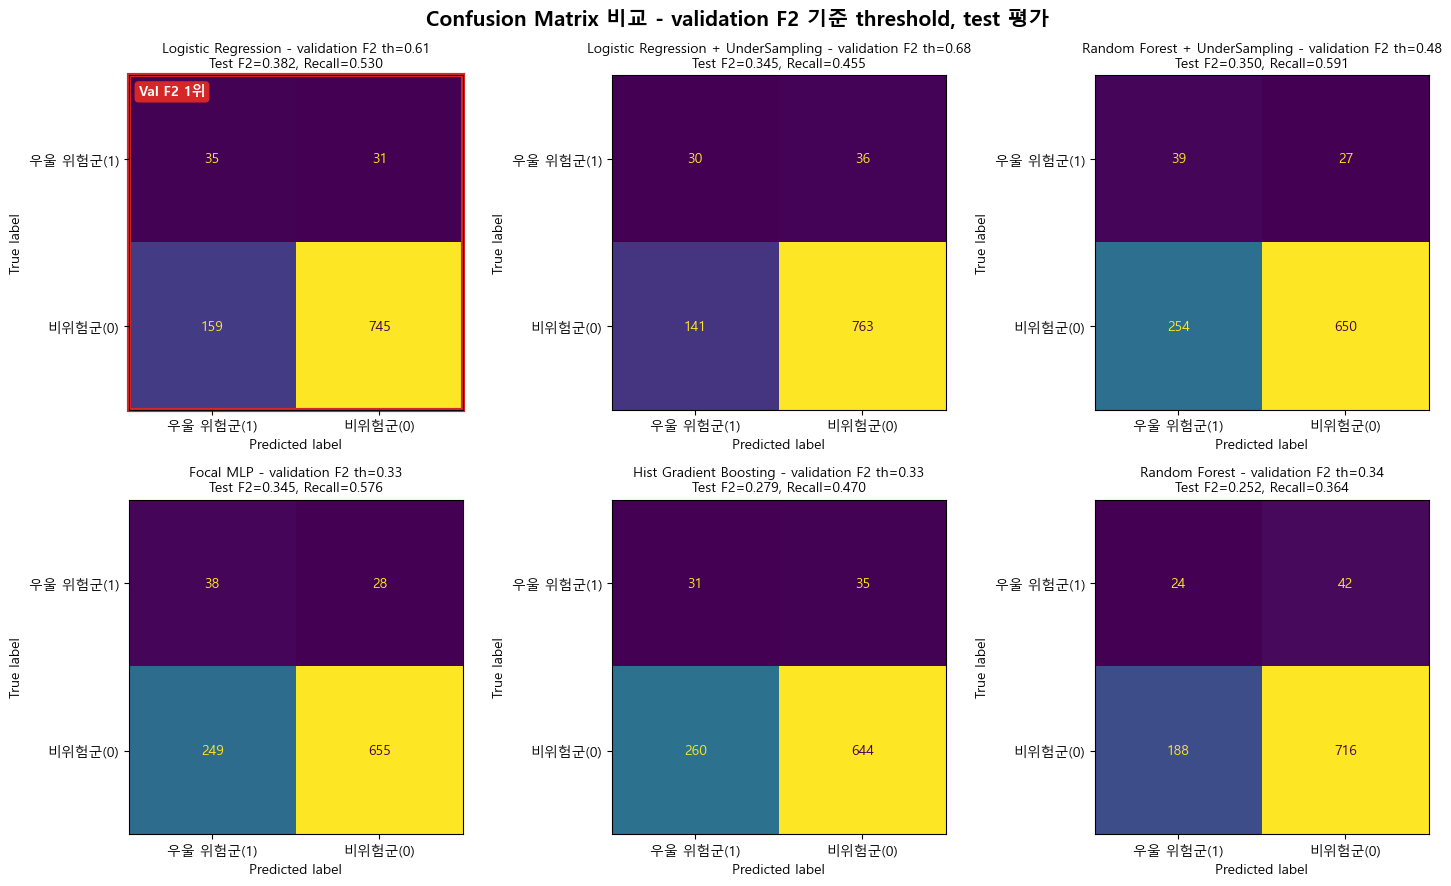

Saved figure: figures\07_validation_screening_confusion_matrix.png


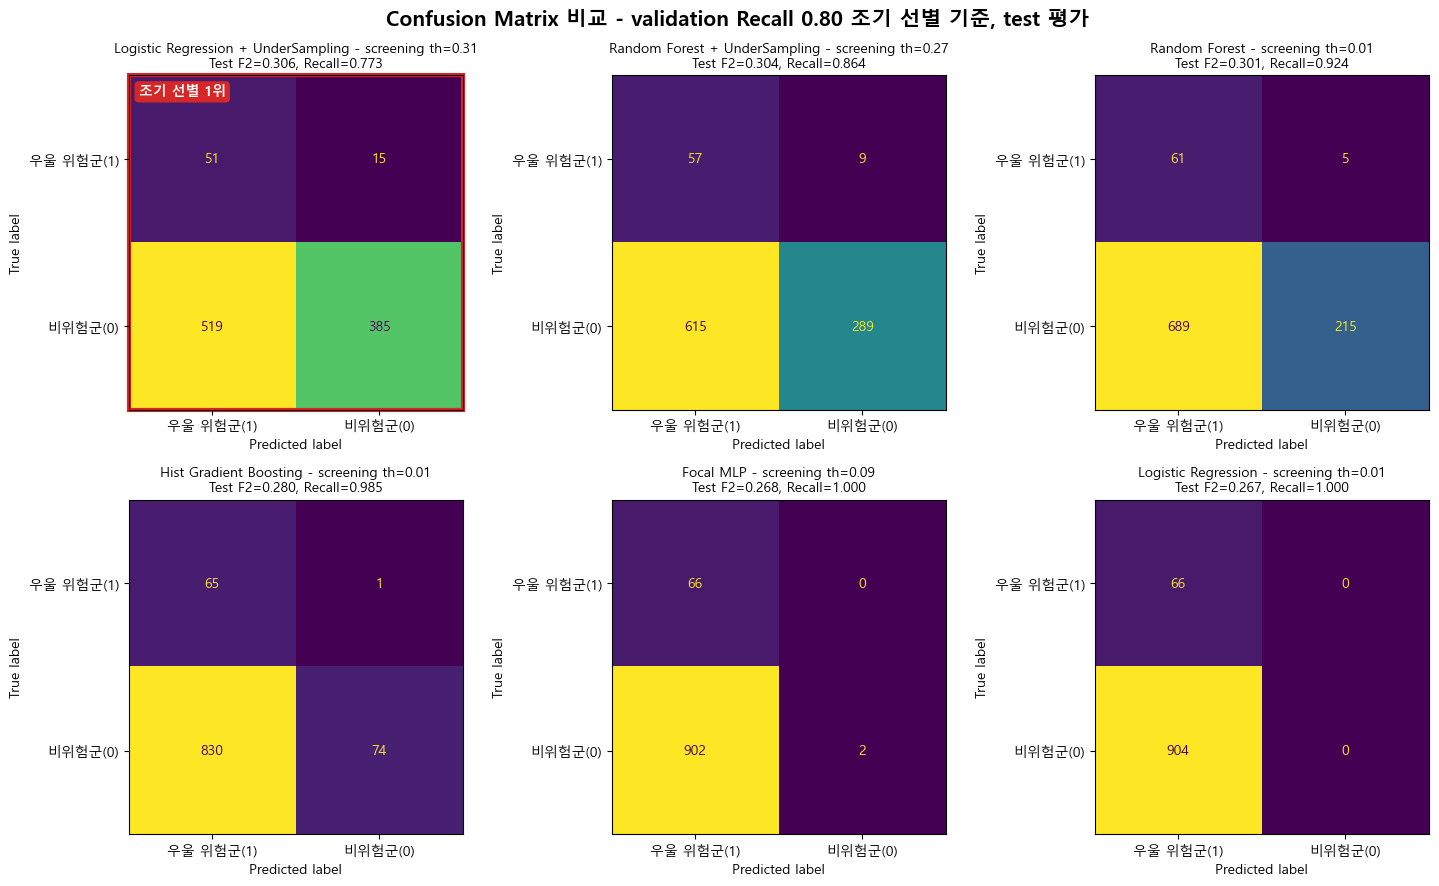

Saved figure: figures\08_roc_pr_curves.png


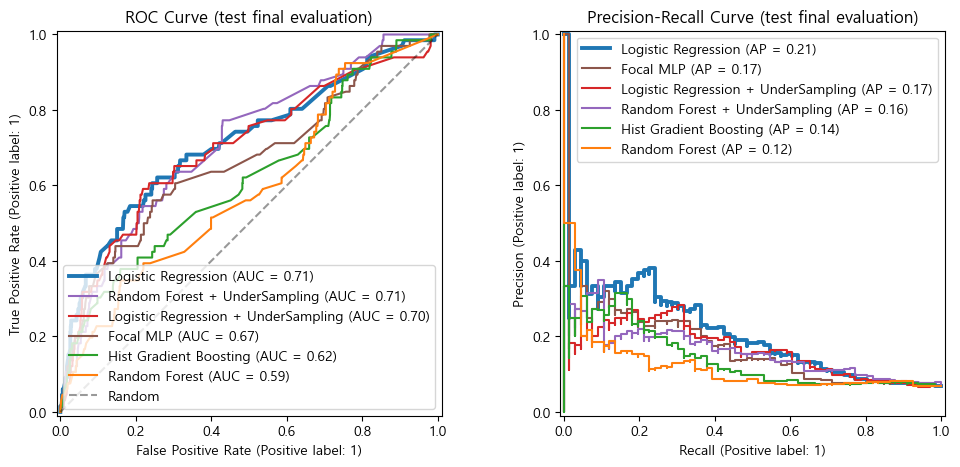

In [58]:
def plot_cm_grid(cm_items, title, ncols=3, filename=None):
    n = len(cm_items)
    nrows = ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5 * ncols, 4.5 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, item in zip(axes, cm_items):
        disp = ConfusionMatrixDisplay(
            confusion_matrix=item["cm"],
            display_labels=["우울 위험군(1)", "비위험군(0)"],
        )
        disp.plot(ax=ax, values_format="d", colorbar=False)
        ax.set_title(item["title"], fontsize=10)

        if item.get("highlight", False):
            ax.add_patch(
                Rectangle(
                    (0, 0), 1, 1,
                    transform=ax.transAxes,
                    fill=False,
                    edgecolor="#d62728",
                    linewidth=3,
                    clip_on=False,
                )
            )
            ax.text(
                0.03, 0.97,
                item.get("highlight_label", "Best"),
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
                fontweight="bold",
                color="white",
                bbox={"boxstyle": "round,pad=0.25", "facecolor": "#d62728", "edgecolor": "#d62728"},
            )

    for ax in axes[len(cm_items):]:
        ax.axis("off")

    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    if filename is not None:
        save_figure(fig, filename, title=title)
    plt.show()


f2_cm_items = []
for _, row in best_threshold_by_model.iterrows():
    name = row["model"]
    threshold = row["threshold"]
    pipe = pipelines[name]
    y_pred_f2, _ = predict_with_threshold(pipe, X_test, threshold)

    f2_cm_items.append({
        "title": f"{name} - validation F2 th={threshold}\nTest F2={row['F2']:.3f}, Recall={row['Recall']:.3f}",
        "cm": confusion_matrix(y_test, y_pred_f2, labels=[1, 0]),
        "highlight": name == final_f2_model_name,
        "highlight_label": "Val F2 1위",
    })

plot_cm_grid(
    f2_cm_items,
    title="Confusion Matrix 비교 - validation F2 기준 threshold, test 평가",
    ncols=3,
    filename="06_validation_f2_confusion_matrix.png",
)

screening_cm_items = []
for _, row in early_screening_by_model.iterrows():
    name = row["model"]
    threshold = row["threshold"]
    pipe = pipelines[name]
    y_pred_screening, _ = predict_with_threshold(pipe, X_test, threshold)

    screening_cm_items.append({
        "title": f"{name} - screening th={threshold}\nTest F2={row['F2']:.3f}, Recall={row['Recall']:.3f}",
        "cm": confusion_matrix(y_test, y_pred_screening, labels=[1, 0]),
        "highlight": name == early_screening_model_name,
        "highlight_label": "조기 선별 1위",
    })

plot_cm_grid(
    screening_cm_items,
    title=f"Confusion Matrix 비교 - validation Recall {SCREENING_TARGET_RECALL:.2f} 조기 선별 기준, test 평가",
    ncols=3,
    filename="07_validation_screening_confusion_matrix.png",
)

curve_summary_df = results_df[["model", "ROC-AUC", "PR-AUC"]].drop_duplicates().reset_index(drop=True)
roc_order = curve_summary_df.sort_values("ROC-AUC", ascending=False)["model"].tolist()
pr_order = curve_summary_df.sort_values("PR-AUC", ascending=False)["model"].tolist()
model_colors = dict(zip(pipelines.keys(), plt.rcParams["axes.prop_cycle"].by_key()["color"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.18})

for rank, name in enumerate(roc_order):
    scores = test_score_cache[name]
    RocCurveDisplay.from_predictions(
        y_test,
        scores,
        ax=axes[0],
        name=name,
        color=model_colors[name],
        linewidth=2.8 if rank == 0 else 1.5,
    )
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[0].set_title("ROC Curve (test final evaluation)")
axes[0].legend()

for rank, name in enumerate(pr_order):
    scores = test_score_cache[name]
    PrecisionRecallDisplay.from_predictions(
        y_test,
        scores,
        ax=axes[1],
        name=name,
        color=model_colors[name],
        linewidth=2.8 if rank == 0 else 1.5,
    )
axes[1].set_title("Precision-Recall Curve (test final evaluation)")
axes[1].legend()

save_figure(fig, "08_roc_pr_curves.png", title="ROC and PR curves on test set")
plt.show()


#### 실행 결과 해석

시각화 결과는 모델별 confusion matrix와 ROC/PR curve를 함께 보여준다. F2 최적 기준과 Recall 0.80 이상 조기 선별 기준은 서로 다른 운영 목표를 가진다. 조기 선별 기준에서는 우울 위험군을 더 많이 잡아내는 대신 비위험군을 위험군으로 분류하는 사례가 늘어나며, 이 trade-off를 confusion matrix에서 직접 확인할 수 있다.


## 11.3 두 가지 최종 선택 모델 성능 확인

여기서는 validation 기준으로 선택된 threshold를 고정하고 test set에서 최종 성능 보고서를 출력한다. test set은 모델 또는 threshold 선택에 사용하지 않는다.

=== 최종 선택 1: validation F2-score 최상위 모델 ===
Model: Logistic Regression
Threshold: 0.61 (selected on validation set)
Test F2: 0.3821
Test Recall: 0.5303
Test Precision: 0.1804
Test PR-AUC: 0.2128
※ report에서 label 1이 PHQ8 기준 우울 위험군입니다.
              precision    recall  f1-score   support

           0       0.96      0.82      0.89       904
           1       0.18      0.53      0.27        66

    accuracy                           0.80       970
   macro avg       0.57      0.68      0.58       970
weighted avg       0.91      0.80      0.84       970


=== 최종 선택 2: validation Recall 0.80 이상 조기 선별 모델 ===
Model: Logistic Regression + UnderSampling
Threshold: 0.31 (selected on validation set)
Test F2: 0.3058
Test Recall: 0.7727
Test Precision: 0.0895
Test PR-AUC: 0.1660
※ report에서 label 1이 PHQ8 기준 우울 위험군입니다.
              precision    recall  f1-score   support

           0       0.96      0.43      0.59       904
           1       0.09      0.77      0.16        66

    accuracy    

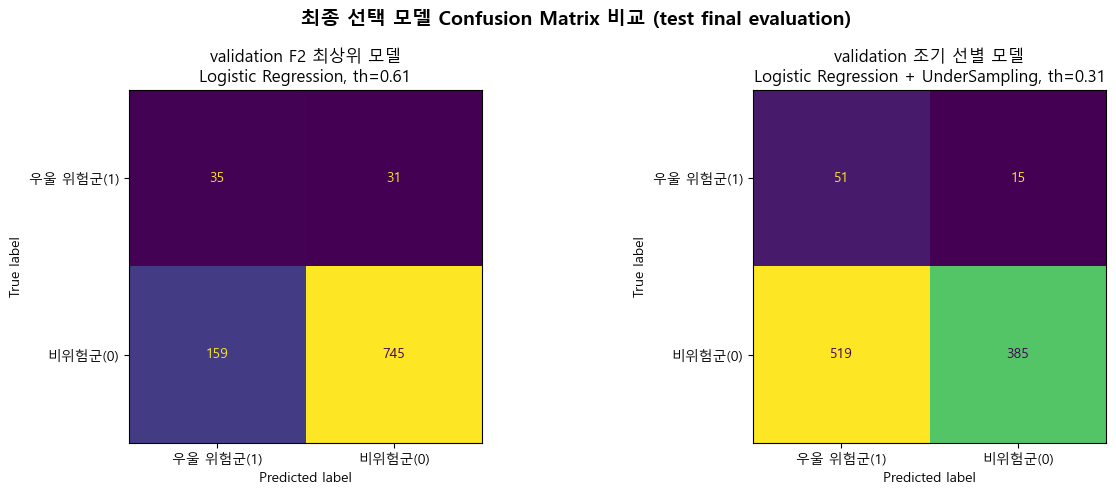

In [59]:
def print_selected_model_report(title, row, pipe):
    threshold = row["threshold"]
    y_pred, _ = predict_with_threshold(pipe, X_test, threshold)

    print(f"=== {title} ===")
    print(f"Model: {row['model']}")
    print(f"Threshold: {threshold} (selected on validation set)")
    print(f"Test F2: {row['F2']:.4f}")
    print(f"Test Recall: {row['Recall']:.4f}")
    print(f"Test Precision: {row['Precision']:.4f}")
    print(f"Test PR-AUC: {row['PR-AUC']:.4f}")
    print("※ report에서 label 1이 PHQ8 기준 우울 위험군입니다.")
    print(classification_report(y_test, y_pred, zero_division=0))
    print()

    return y_pred


y_pred_final_f2 = print_selected_model_report(
    "최종 선택 1: validation F2-score 최상위 모델",
    final_f2_best_row,
    final_f2_pipe,
)

y_pred_early_screening = print_selected_model_report(
    f"최종 선택 2: validation Recall {SCREENING_TARGET_RECALL:.2f} 이상 조기 선별 모델",
    early_screening_best_row,
    early_screening_pipe,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_f2 = confusion_matrix(y_test, y_pred_final_f2, labels=[1, 0])
disp_f2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_f2,
    display_labels=["우울 위험군(1)", "비위험군(0)"],
)
disp_f2.plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title(
    f"validation F2 최상위 모델\n{final_f2_model_name}, th={final_f2_threshold}"
)

cm_screening = confusion_matrix(y_test, y_pred_early_screening, labels=[1, 0])
disp_screening = ConfusionMatrixDisplay(
    confusion_matrix=cm_screening,
    display_labels=["우울 위험군(1)", "비위험군(0)"],
)
disp_screening.plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title(
    f"validation 조기 선별 모델\n{early_screening_model_name}, th={early_screening_threshold}"
)

fig.suptitle("최종 선택 모델 Confusion Matrix 비교 (test final evaluation)", fontsize=14, fontweight="bold")
save_figure(fig, "12_confusion_matrix_best_model.png", title="Final selected model confusion matrices")
plt.show()


## 11.4 Overfitting 점검

Validation에서 선택된 threshold를 고정한 뒤 train, validation, test 성능을 함께 비교한다. 이 표는 모델 선택을 새로 수행하기 위한 것이 아니라, 최종 평가 결과가 train 성능에 비해 과도하게 낙관적인지 점검하기 위한 진단용 산출물이다.

,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate,split,threshold_source,selection_rule
11,Focal MLP,0.33,0.665770,0.173451,0.215297,0.344828,0.132404,0.575758,0.714433,0.724558,38,28,249,655,287,0.295876,test,validation,validation_F2
9,Focal MLP,0.33,0.818214,0.366214,0.265290,0.441332,0.159351,0.791469,0.701613,0.695050,167,44,881,2008,1048,0.338065,train,validation,validation_F2
10,Focal MLP,0.33,0.662465,0.170324,0.217949,0.360934,0.131274,0.641509,0.685567,0.688797,34,19,225,498,259,0.333763,validation,validation,validation_F2
14,Hist Gradient Boosting,0.33,0.619310,0.140598,0.173669,0.279279,0.106529,0.469697,0.695876,0.712389,31,35,260,644,291,0.300000,test,validation,validation_F2
12,Hist Gradient Boosting,0.33,0.871404,0.457682,0.285714,0.473656,0.171981,0.843602,0.712903,0.703358,178,33,857,2032,1035,0.333871,train,validation,validation_F2
13,Hist Gradient Boosting,0.33,0.622067,0.188404,0.216783,0.348315,0.133047,0.584906,0.711340,0.720609,31,22,202,521,233,0.300258,validation,validation,validation_F2
2,Logistic Regression,0.61,0.712968,0.212769,0.269231,0.382096,0.180412,0.530303,0.804124,0.824115,35,31,159,745,194,0.200000,test,validation,validation_F2
0,Logistic Regression,0.61,0.734592,0.174691,0.261283,0.372881,0.174326,0.521327,0.799355,0.819661,110,101,521,2368,631,0.203548,train,validation,validation_F2
1,Logistic Regression,0.61,0.683290,0.232218,0.288462,0.408719,0.193548,0.566038,0.809278,0.827109,30,23,125,598,155,0.199742,validation,validation,validation_F2
5,Logistic Regression + UnderSampling,0.68,0.698419,0.166026,0.253165,0.344828,0.175439,0.454545,0.817526,0.844027,30,36,141,763,171,0.176289,test,validation,validation_F2


Saved figure: figures\15_overfitting_check.png


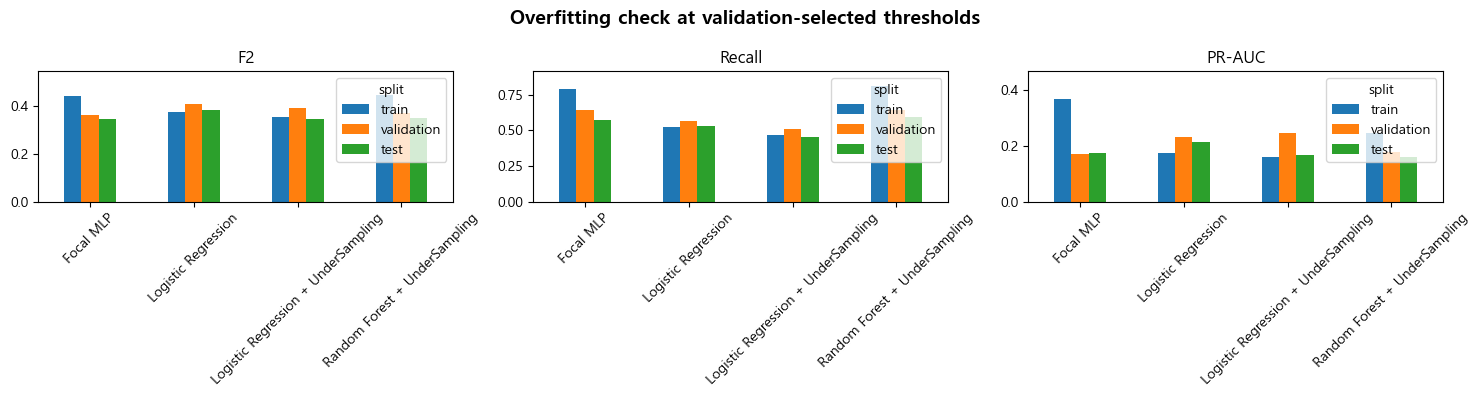

In [60]:
overfitting_rows = []

split_data = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "test": (X_test, y_test),
}

for _, selected_row in selected_threshold_df.iterrows():
    name = selected_row["model"]
    threshold = selected_row["threshold"]
    pipe = pipelines[name]

    for split_name, (X_split, y_split) in split_data.items():
        score = get_positive_score(pipe, X_split)
        row = metric_row(y_split, score, threshold, model_name=name)
        row["split"] = split_name
        row["threshold_source"] = "validation"
        row["selection_rule"] = "validation_F2"
        overfitting_rows.append(row)

overfitting_check_df = pd.DataFrame(overfitting_rows)
overfitting_check_df.to_csv(
    os.path.join(OUTPUT_DIR, "overfitting_check.csv"),
    index=False,
    encoding="utf-8-sig",
)

display(overfitting_check_df.sort_values(["model", "split"]))

plot_metrics = ["F2", "Recall", "PR-AUC"]
plot_df = overfitting_check_df[
    overfitting_check_df["model"].isin(results_df.head(4)["model"])
].copy()

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5 * len(plot_metrics), 4), sharex=True)
if len(plot_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, plot_metrics):
    pivot = plot_df.pivot(index="model", columns="split", values=metric)
    pivot = pivot[[c for c in ["train", "validation", "test"] if c in pivot.columns]]
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylim(0, min(1.0, max(0.1, float(np.nanmax(pivot.values)) + 0.1)))
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Overfitting check at validation-selected thresholds", fontsize=14, fontweight="bold")
save_figure(fig, "15_overfitting_check.png", title="Overfitting check")
plt.show()


#### 실행 결과 해석

최종 비교는 validation에서 선택된 threshold를 고정한 뒤 test set에서 산출한 `results_df`와 `screening_results_df`를 기준으로 해석한다. 조기 선별 모델은 위험군을 더 넓게 포착하는 대신 False Positive가 증가할 수 있으므로, 단독 판단보다 추가 검사나 상담으로 연결하기 위한 넓은 1차 필터로 보는 것이 적절하다.


---

# 12. 변수 중요도 및 해석

Random Forest 또는 Gradient Boosting 계열 모델의 중요도를 확인한다. One-Hot Encoding 이후 변수명이 확장되므로, 전처리 후 feature name을 확인하여 해석한다.


,feature,importance
16,act_limit_yes,0.218737
1,wknd_sleep_hours,0.133122
0,wkdy_sleep_hours,0.128885
2,sleep_diff,0.104560
11,ear_noise_min_clean,0.099462
3,sleep_short,0.051436
9,occ_noise_yes,0.043130
15,tinnitus_dist_score,0.035809
10,ear_noise_use,0.028327
13,tinnitus_use,0.025946


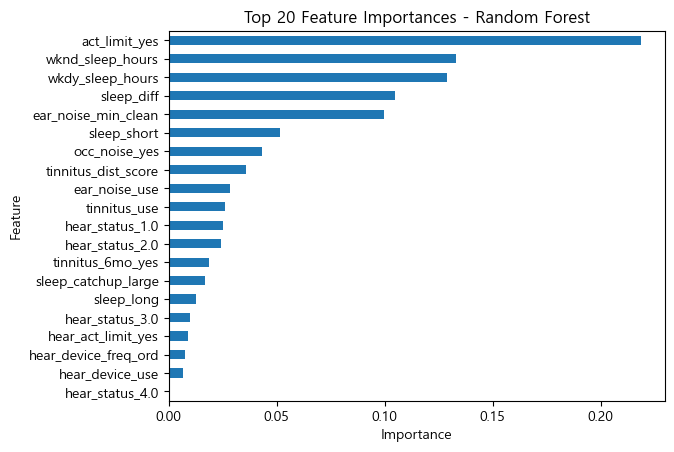

In [61]:
def get_feature_names_from_preprocessor(preprocessor):
    feature_names = []

    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_features)

    if "cat" in preprocessor.named_transformers_ and categorical_features:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        cat_names = onehot.get_feature_names_out(categorical_features)
        feature_names.extend(cat_names)

    return np.array(feature_names)

rf_pipe = pipelines["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
feature_names = get_feature_names_from_preprocessor(rf_pipe.named_steps["preprocessor"])

if hasattr(rf_model, "feature_importances_"):
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importances.head(20))

    importances.head(20).sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
    )
    plt.title("Top 20 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()


#### 실행 결과 해석

Random Forest의 내장 feature importance에서는 활동제한, 수면시간 및 수면 패턴, 이어폰 소음 시간 관련 변수가 상대적으로 높은 중요도를 보였다. 이는 모델이 해당 변수군을 많이 사용했음을 보여주지만, Random Forest 내장 중요도는 변수 스케일과 분할 구조의 영향을 받을 수 있으므로 permutation importance와 SHAP을 함께 확인해야 한다.


## 12.1 Permutation Importance

최종 선별 모델의 해석은 validation 기준으로 선택된 대표 모델을 대상으로 한다. test set은 최종 평가에만 남겨두기 위해 permutation importance는 validation set에서 계산한다.

Permutation importance model: Logistic Regression
Permutation importance split: validation


,feature,importance_mean,importance_std
13,act_limit_yes,0.119153,0.025237
15,sleep_short,0.059449,0.017955
12,tinnitus_dist_score,0.021236,0.006813
17,sleep_diff,0.010964,0.011560
16,sleep_long,0.007206,0.014441
14,hear_act_limit_yes,0.001502,0.002252
6,occ_noise_yes,0.001165,0.001003
7,ear_noise_use,0.000809,0.008382
3,hear_device_use,0.000513,0.001138
0,wkdy_sleep_hours,0.000403,0.001603


Saved figure: figures\13_feature_importance.png


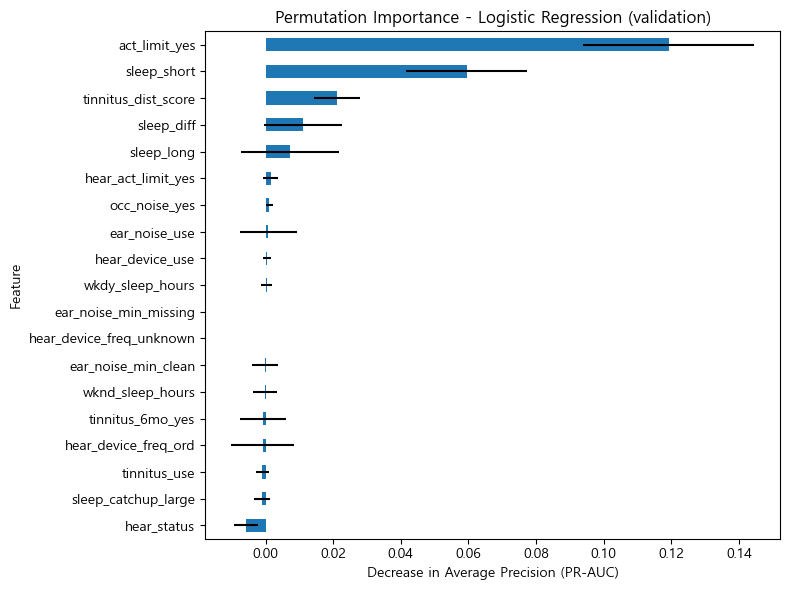

In [62]:
from sklearn.inspection import permutation_importance

if "final_f2_model_name" in globals():
    best_model_name = final_f2_model_name
elif "final_model_name" in globals():
    best_model_name = final_model_name
else:
    best_model_name = selected_threshold_df.iloc[0]["model"]

best_pipe = pipelines[best_model_name]

print(f"Permutation importance model: {best_model_name}")
print("Permutation importance split: validation")

perm_result = permutation_importance(
    best_pipe,
    X_val,
    y_val,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="average_precision",
)

perm_importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_importance)

ax = perm_importance.sort_values("importance_mean").plot(
    kind="barh",
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    legend=False,
    figsize=(8, 6)
)
ax.set_title(f"Permutation Importance - {best_model_name} (validation)")
ax.set_xlabel("Decrease in Average Precision (PR-AUC)")
ax.set_ylabel("Feature")
save_current_figure("13_feature_importance.png", title="Permutation importance on validation set")
plt.show()


#### 실행 결과 해석

Permutation importance는 F2-score 기준 최종 모델인 Logistic Regression을 대상으로 validation set에서 계산되었다. 상위 변수와 순위는 위 표 및 `figures/13_feature_importance.png`를 기준으로 확인하며, 이 결과는 특정 변수를 섞었을 때 모델의 소수 클래스 탐지 성능이 얼마나 낮아지는지 보여주는 해석이다.


## 12.2 SHAP 설치 확인

SHAP 분석 셀을 실행하기 전에 `shap`이 설치되어 있어야 한다.  
설치가 필요하면 아래 명령을 별도 셀에서 한 번만 실행한다.

```python
%pip install shap
```


## 12.3 SHAP 적용 준비: Random Forest 기반 비선형 보조 분석

본 섹션의 SHAP 분석은 최종 threshold 적용 모델 자체를 설명하기 위한 분석이 아니라, 수면·청각·소음 관련 변수들이 **비선형 모델에서** PHQ8 기준 우울 위험군 분류에 어떤 방식으로 기여하는지 탐색하기 위한 보조 분석이다. 최종 선별 모델의 해석은 Logistic Regression 등 validation 기준 최종 모델의 threshold 조정 결과와 해당 모델 기준 permutation importance를 중심으로 해석한다.

여러 모델 중 Random Forest를 SHAP 분석 대상으로 선택한 이유는 다음과 같다. Logistic Regression은 선형 모델이므로 계수와 permutation importance를 통해 비교적 직접적인 해석이 가능하지만, 수면시간, 청각 문제, 소음 노출과 우울 위험군 사이의 관계는 단순 선형 관계로만 설명되기 어려울 수 있다. Random Forest는 변수 간 상호작용과 비선형적인 분할 구조를 학습할 수 있으므로, 선형 모델에서 드러나기 어려운 변수 영향의 방향과 패턴을 탐색하는 데 적합하다.

따라서 본 섹션의 Random Forest SHAP은 “최종 모델의 직접 해석”이 아니라, 최종 모델 해석을 보완하는 비선형 탐색적 설명으로 사용한다. SHAP은 Random Forest 파이프라인의 전처리 후 feature matrix를 기준으로 계산되며, test set을 threshold 선택이나 해석 선택에 사용하지 않기 위해 validation set을 변환해 계산한다. 이 결과는 인과관계가 아니라 Random Forest가 학습한 비선형 예측 패턴에 대한 제한적 설명으로 해석한다.

In [63]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError as e:
    SHAP_AVAILABLE = False
    raise ImportError(
        "SHAP 분석을 실행하려면 먼저 `%pip install shap`을 실행하세요."
    ) from e

# Random Forest 기준 보조 분석
rf_pipe = pipelines["Random Forest"]
rf_preprocessor = rf_pipe.named_steps["preprocessor"]
rf_model = rf_pipe.named_steps["model"]

X_val_transformed = rf_preprocessor.transform(X_val)

if hasattr(X_val_transformed, "toarray"):
    X_val_transformed = X_val_transformed.toarray()

feature_names = get_feature_names_from_preprocessor(rf_preprocessor)

X_shap_base = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val.index
)

print("SHAP analysis model: Random Forest")
print("SHAP analysis split: validation")
print("SHAP 분석용 validation 데이터 크기:", X_shap_base.shape)
X_shap_base.head()


SHAP analysis model: Random Forest
SHAP analysis split: validation
SHAP 분석용 validation 데이터 크기: (776, 22)


,wkdy_sleep_hours,wknd_sleep_hours,sleep_diff,sleep_short,sleep_long,sleep_catchup_large,hear_device_use,hear_device_freq_ord,hear_device_freq_unknown,occ_noise_yes,ear_noise_use,ear_noise_min_clean,ear_noise_min_missing,tinnitus_use,tinnitus_6mo_yes,tinnitus_dist_score,act_limit_yes,hear_act_limit_yes,hear_status_1.0,hear_status_2.0,hear_status_3.0,hear_status_4.0
1817,0.218572,1.562238,1.794806,-0.440619,-0.24534,1.891831,-0.1186,-0.100241,0.0,2.816686,-0.347494,-0.236835,0.0,-0.284018,-0.261206,-0.22543,-0.461338,-0.112876,1.0,0.0,0.0,0.0
3117,-0.542745,-0.876608,-0.570797,-0.440619,-0.24534,-0.528588,-0.1186,-0.100241,0.0,-0.355027,-0.347494,-0.236835,0.0,-0.284018,-0.261206,-0.22543,-0.461338,-0.112876,0.0,1.0,0.0,0.0
4292,-0.542745,-0.876608,-0.570797,-0.440619,-0.24534,-0.528588,-0.1186,-0.100241,0.0,-0.355027,-0.347494,-0.236835,0.0,-0.284018,-0.261206,-0.22543,-0.461338,-0.112876,1.0,0.0,0.0,0.0
5125,0.979889,0.952526,0.217737,-0.440619,-0.24534,-0.528588,-0.1186,-0.100241,0.0,-0.355027,-0.347494,-0.236835,0.0,-0.284018,-0.261206,-0.22543,2.167609,-0.112876,1.0,0.0,0.0,0.0
1845,0.218572,1.562238,1.794806,-0.440619,-0.24534,1.891831,-0.1186,-0.100241,0.0,-0.355027,-0.347494,-0.236835,0.0,-0.284018,-0.261206,-0.22543,-0.461338,-0.112876,1.0,0.0,0.0,0.0


#### 실행 결과 해석

SHAP 분석을 위해 Random Forest 파이프라인의 전처리 결과를 추출했다. validation set 776명은 one-hot encoding 이후 22개의 feature로 변환되었다. 이 변환된 feature 공간을 기준으로 SHAP 값이 계산되므로, 이후 해석에서는 encoded feature와 원래 설문 변수 간 매핑을 함께 고려해야 한다. 이 분석은 최종 Logistic Regression 선별 모델의 SHAP 해석이 아니라 Random Forest 기반 보조 분석이다.


## 12.4 SHAP 값 계산

Random Forest 모델에 대해 TreeExplainer를 사용해 우울 위험군 클래스(1)에 대한 SHAP 값을 계산한다. 계산 시간이 길어질 수 있으므로 validation set 전체가 아니라 최대 1,000개 샘플을 추출해 방향성과 주요 패턴을 확인한다. 이 결과는 최종 모델의 직접 설명이 아니라 비선형 모델에서의 변수 영향 탐색으로 제한한다.

In [64]:
shap_sample_size = min(1000, len(X_shap_base))

X_shap_sample = X_shap_base.sample(
    n=shap_sample_size,
    random_state=RANDOM_STATE
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

print("SHAP values shape:", shap_values_class1.shape)


SHAP values shape: (776, 22)


#### 실행 결과 해석

SHAP 값은 `776 × 22` 형태로 계산되었다. 행은 validation set 대상자, 열은 전처리 후 feature를 의미한다. 이 값은 Random Forest에서 각 feature가 우울 위험군 클래스(1)의 예측값을 높이는지 낮추는지, 그리고 어느 정도 영향을 주는지를 확인하는 데 사용된다. 최종 선별 모델 자체의 해석은 Logistic Regression의 threshold 조정 결과와 permutation importance를 중심으로 본다.


## 12.5 SHAP Summary Plot

Summary plot은 변수별 영향력의 크기와 방향성을 동시에 보여준다. 점이 오른쪽에 위치할수록 해당 변수가 PHQ8 기준 우울 위험군(1) 선별을 높이는 방향으로 작용한 것으로 해석한다.


Saved figure: figures\14_shap_summary_rf_validation.png


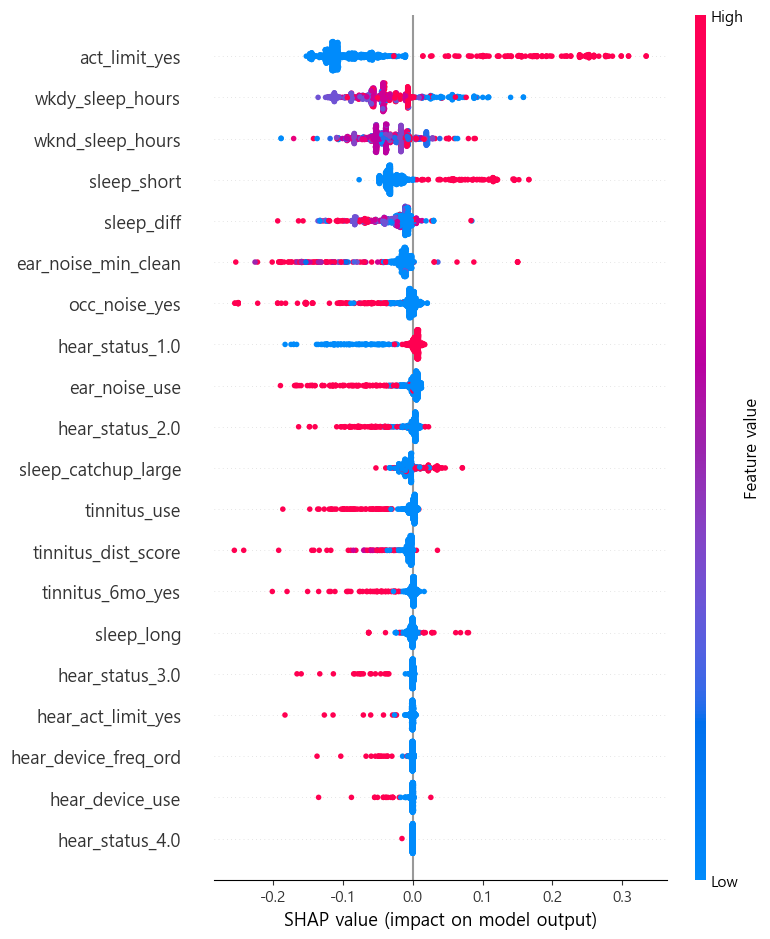

In [65]:
shap.summary_plot(
    shap_values_class1,
    X_shap_sample,
    plot_type="dot",
    max_display=20,
    show=False,
)
save_current_figure("14_shap_summary_rf_validation.png", title="Random Forest SHAP summary on validation set")
plt.show()


#### 실행 결과 해석

SHAP summary plot은 Random Forest 보조 분석에서 변수별 영향력 크기와 방향성을 동시에 보여준다. 위쪽에 위치한 변수일수록 평균적으로 예측에 더 크게 기여한다. 점의 위치가 오른쪽이면 우울 위험군 선별 확률을 높이는 방향, 왼쪽이면 낮추는 방향으로 작용한 것으로 해석한다. 다만 이는 인과관계가 아니라 해당 모델의 예측 패턴에 대한 설명이다.


## 12.6 원래 변수 단위의 SHAP 중요도

One-hot encoding으로 나뉜 범주형 feature는 원래 변수 단위로 합산해 해석한다. 이를 통해 모델 입력 feature 수준이 아니라 설문 변수 수준에서 어떤 요인이 중요했는지 확인한다.


,original_feature,mean_abs_shap
0,act_limit_yes,0.114174
1,wkdy_sleep_hours,0.049614
2,wknd_sleep_hours,0.040099
3,sleep_short,0.037124
4,hear_status,0.030765
5,sleep_diff,0.028443
6,ear_noise_min_clean,0.025909
7,occ_noise_yes,0.018143
8,ear_noise_use,0.014911
9,sleep_catchup_large,0.010152


Saved figure: figures\14b_shap_original_variable_rf_validation.png


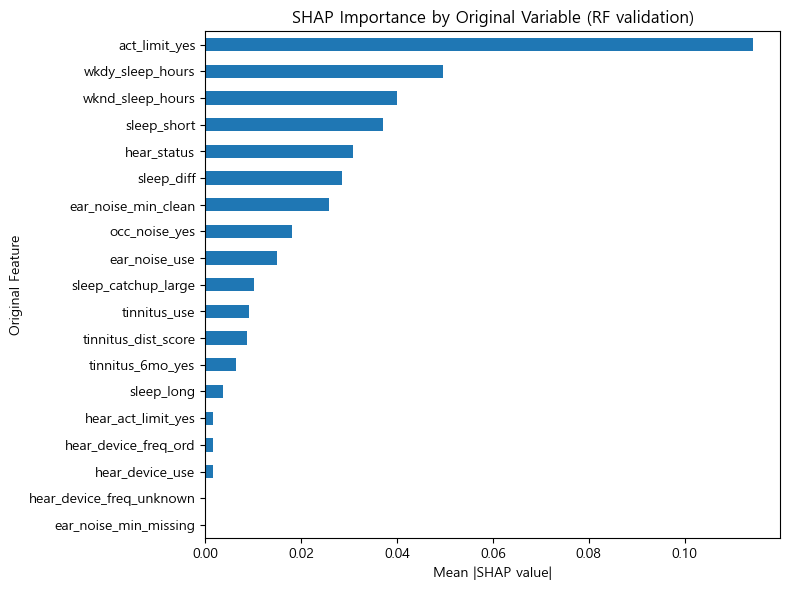

In [66]:
shap_importance = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

def map_original_feature_from_encoded(encoded_name):
    for col in categorical_features:
        if encoded_name.startswith(col + "_"):
            return col
    return encoded_name

shap_importance["original_feature"] = shap_importance["feature"].apply(
    map_original_feature_from_encoded
)

original_shap_importance = (
    shap_importance
    .groupby("original_feature")["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

display(original_shap_importance)

original_shap_importance.sort_values("mean_abs_shap").plot(
    kind="barh",
    x="original_feature",
    y="mean_abs_shap",
    legend=False,
    figsize=(8, 6)
)

plt.title("SHAP Importance by Original Variable (RF validation)")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Original Feature")
save_current_figure("14b_shap_original_variable_rf_validation.png", title="Random Forest SHAP importance by original variable")
plt.show()


#### 실행 결과 해석

One-hot encoding으로 나뉜 feature를 원래 변수 단위로 다시 묶어 Random Forest SHAP 중요도를 계산했다. 상위 변수와 순위는 위 표 및 `figures/14b_shap_original_variable_rf_validation.png`를 기준으로 확인하며, 전반적으로 활동제한, 수면시간 및 수면 패턴, 청각·소음 관련 지표가 비선형 모델에서도 PHQ8 기준 위험군 선별에 일부 정보를 제공했는지 확인하는 보조 자료이다.


## 12.7 수면시간 변수의 SHAP 방향성 확인

수면시간 관련 변수는 선별 방향성이 중요하므로 Random Forest SHAP dependence plot으로 별도 확인한다. 각 subplot은 해당 변수 값이 변할 때 PHQ8 기준 우울 위험군(1) 선별에 대한 SHAP 값이 어떻게 달라지는지 보여준다.


Saved figure: figures\14c_shap_sleep_direction_rf_validation.png


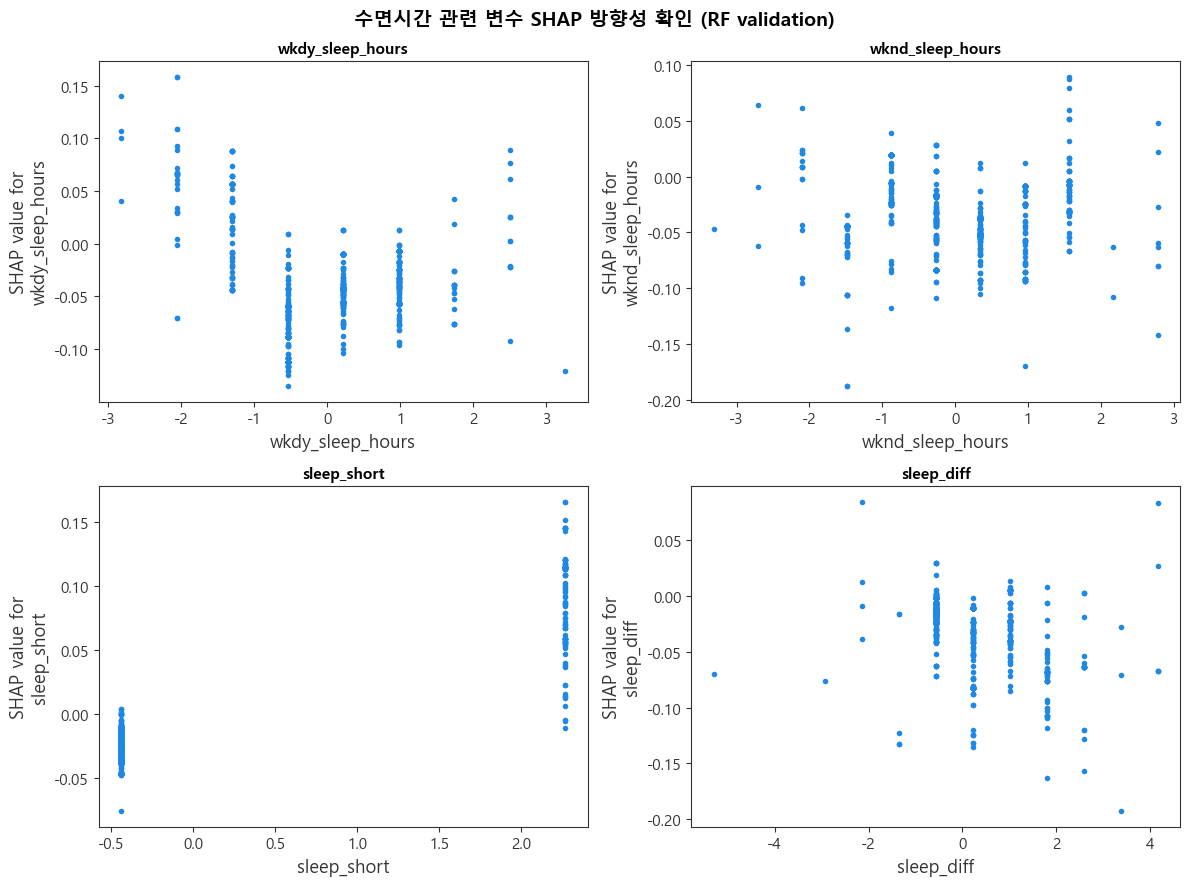

In [67]:
sleep_features_to_check = [
    "wkdy_sleep_hours",
    "wknd_sleep_hours",
    "sleep_short",
    "sleep_diff",
]

available_sleep_features = [
    feature for feature in sleep_features_to_check
    if feature in X_shap_sample.columns
]

if len(available_sleep_features) == 0:
    print("확인 가능한 수면시간 관련 변수가 X_shap_sample에 없습니다.")
else:
    ncols = 2
    nrows = int(np.ceil(len(available_sleep_features) / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4.5 * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, feature in zip(axes, available_sleep_features):
        shap.dependence_plot(
            feature,
            shap_values_class1,
            X_shap_sample,
            interaction_index=None,
            ax=ax,
            show=False,
        )
        ax.set_title(feature, fontsize=11, fontweight="bold")
        ax.set_frame_on(True)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_color("#333333")

    for ax in axes[len(available_sleep_features):]:
        ax.axis("off")

    fig.suptitle("수면시간 관련 변수 SHAP 방향성 확인 (RF validation)", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    save_figure(fig, "14c_shap_sleep_direction_rf_validation.png", title="Random Forest SHAP sleep feature direction")
    plt.show()


#### 실행 결과 해석

수면 관련 변수의 Random Forest SHAP dependence plot을 통해 수면시간과 파생변수가 위험군 선별 방향에 어떻게 작용하는지 확인했다. 이 그래프는 수면시간이 짧거나 수면 패턴 차이가 클 때 SHAP 값이 어떤 방향으로 이동하는지 보는 용도이며, 결과는 인과관계가 아니라 비선형 모델 내부의 예측 방향성으로 해석해야 한다.


## 12.8 PHQ8 기준 우울 위험군 선별 사례 목록 확인

Random Forest 보조 분석에서 개별 사례 해석에 사용할 후보를 고르기 위해 validation set에서 Random Forest가 우울 위험군으로 선별한 사례를 확인한다. 이 목록은 임상 판단 대상자 목록이 아니라, 비선형 모델이 어떤 입력 조합을 위험군 방향으로 해석했는지 살펴보기 위한 보조 분석용 자료이다.

In [68]:
y_pred = rf_pipe.predict(X_val)
y_pred_proba = rf_pipe.predict_proba(X_val)[:, 1]

pred_result = X_val.copy()
pred_result["actual"] = y_val.values
pred_result["predicted"] = y_pred
pred_result["pred_proba_depression"] = y_pred_proba

pred_result["validation_order"] = range(len(pred_result))
pred_result["original_index"] = pred_result.index

depression_predicted = pred_result[pred_result["predicted"] == 1].sort_values(
    "pred_proba_depression",
    ascending=False
)

display(depression_predicted)


,wkdy_sleep_hours,wknd_sleep_hours,hear_status,hear_device_use,hear_device_freq_ord,hear_device_freq_unknown,occ_noise_yes,ear_noise_use,ear_noise_min_clean,ear_noise_min_missing,tinnitus_use,tinnitus_6mo_yes,tinnitus_dist_score,act_limit_yes,hear_act_limit_yes,sleep_short,sleep_long,sleep_diff,sleep_catchup_large,actual,predicted,pred_proba_depression,validation_order,original_index
466,7.0,9.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0,0,2.0,1,1,1,0.881260,365,466
5713,4.0,4.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,1,0,0.0,0,0,1,0.847825,10,5713
2425,4.0,4.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,1,0,0.0,0,0,1,0.847825,336,2425
1469,4.0,7.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,0,3.0,1,1,1,0.841678,425,1469
5459,4.0,7.0,1.0,NaN,NaN,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,0,3.0,1,0,1,0.841678,58,5459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5397,8.0,8.0,1.0,NaN,NaN,0,NaN,1.0,120.0,0,NaN,NaN,NaN,0.0,0.0,0,0,0.0,0,0,1,0.520947,566,5397
4687,7.0,7.0,1.0,NaN,NaN,0,1.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0,0,0.0,0,0,1,0.511679,224,4687
4460,7.0,7.0,1.0,NaN,NaN,0,1.0,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0,0,0,0.0,0,0,1,0.511679,673,4460
3305,4.0,4.0,1.0,NaN,NaN,0,1.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1,0,0.0,0,0,1,0.500472,328,3305


#### 실행 결과 해석

Random Forest가 우울 위험군으로 선별한 사례를 예측확률 순으로 정렬했다. 이 목록은 개별 사례 SHAP 해석을 위한 후보군이며, 실제 임상 판단 대상자 목록이 아니라 Random Forest가 어떤 입력 조합을 위험군 방향으로 해석했는지 살펴보기 위한 보조 분석용 결과이다.


## 12.9 개별 사례 SHAP 해석

Random Forest에서 PHQ8 기준 우울 위험군 선별 확률이 높은 한 명의 사례를 선택해 force plot으로 해석한다. 각 feature가 해당 개인의 위험군 선별 방향을 위험군 방향으로 밀었는지, 반대로 낮추는 방향으로 작용했는지 확인한다. 이는 최종 Logistic Regression 모델의 개별 진단 설명이 아니라 보조적 사례 해석이다.


In [69]:
if "depression_predicted" in globals() and len(depression_predicted) > 0:
    selected_original_index = depression_predicted.index[0]
else:
    selected_original_index = X_val.index[0]

x_one_raw = X_val.loc[[selected_original_index]]
actual_value = y_val.loc[selected_original_index]
pred_value = rf_pipe.predict(x_one_raw)[0]
pred_proba = rf_pipe.predict_proba(x_one_raw)[0, 1]

print("선택한 original_index:", selected_original_index)
print("실제값:", actual_value)
print("예측값:", pred_value)
print("우울 위험군 선별확률:", pred_proba)

x_one_transformed = rf_preprocessor.transform(x_one_raw)
if hasattr(x_one_transformed, "toarray"):
    x_one_transformed = x_one_transformed.toarray()

x_one_shap = pd.DataFrame(
    x_one_transformed,
    columns=feature_names,
    index=x_one_raw.index,
)

shap_values_one = explainer.shap_values(x_one_shap)

if isinstance(shap_values_one, list):
    shap_values_one_class1 = shap_values_one[1]
else:
    if len(shap_values_one.shape) == 3:
        shap_values_one_class1 = shap_values_one[:, :, 1]
    else:
        shap_values_one_class1 = shap_values_one

expected_value_class1 = (
    explainer.expected_value[1]
    if isinstance(explainer.expected_value, (list, np.ndarray))
    else explainer.expected_value
)

shap.initjs()

shap.force_plot(
    expected_value_class1,
    shap_values_one_class1[0],
    x_one_shap.iloc[0],
)


선택한 original_index: 466
실제값: 1
예측값: 1
우울 위험군 선별확률: 0.8812598731965151


#### 실행 결과 해석

예측확률이 높은 대표 사례 한 명을 선택해 Random Forest 기반 개별 SHAP force plot을 생성했다. 현재 선택된 사례는 실제값과 예측값이 모두 우울 위험군이며, 예측확률은 약 `0.881`이다. Force plot에서는 어떤 feature가 이 사례의 위험군 선별 확률을 높였고 낮췄는지 개별 수준에서 확인할 수 있다. 이 결과는 임상 판단이나 최종 Logistic Regression 모델의 직접 설명으로 사용하지 않는다.


## 12.10 참고: 기존 중요도 결과의 원래 변수 단위 집계

이전 단계에서 `importances` 객체가 만들어져 있는 경우, encoded feature를 원래 변수명으로 묶어 참고용 중요도 표와 그래프를 출력한다. 현재 주요 해석은 permutation importance와 SHAP 결과를 우선한다.


,original_feature,importance
0,act_limit_yes,0.218737
1,wknd_sleep_hours,0.133122
2,wkdy_sleep_hours,0.128885
3,sleep_diff,0.104560
4,ear_noise_min_clean,0.099462
5,hear_status,0.059890
6,sleep_short,0.051436
7,occ_noise_yes,0.043130
8,tinnitus_dist_score,0.035809
9,ear_noise_use,0.028327


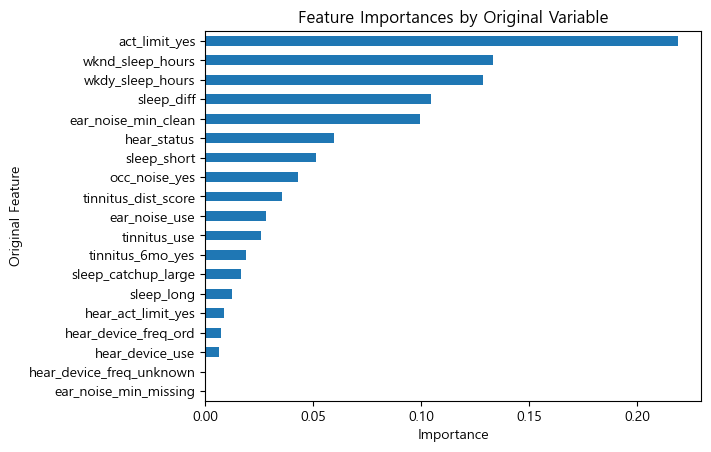

In [70]:
if "importances" in globals():
    grouped_importances = importances.copy()

    def map_original_feature(encoded_name):
        for col in categorical_features:
            if encoded_name.startswith(col + "_"):
                return col
        return encoded_name

    grouped_importances["original_feature"] = grouped_importances["feature"].apply(map_original_feature)
    original_importance = (
        grouped_importances.groupby("original_feature")["importance"]
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    display(original_importance)

    original_importance.sort_values("importance").plot(
        kind="barh",
        x="original_feature",
        y="importance",
        legend=False,
    )
    plt.title("Feature Importances by Original Variable")
    plt.xlabel("Importance")
    plt.ylabel("Original Feature")
    plt.show()


#### 실행 결과 해석

Random Forest 내장 중요도를 원래 변수 단위로 집계했다. 상위 변수와 순위는 위 표 및 그래프를 기준으로 확인하며, 이 결과는 SHAP 및 permutation importance와 함께 참고용으로 사용한다. 단독 결론으로 제시하기보다는 여러 해석 방법 간 일관성을 확인하는 용도로 활용한다.


---

# 13. 결과 해석 정리

## 13.1 모델 성능 해석 예시

모델 성능은 Accuracy 중심으로 해석하지 않는다. 우울 위험군은 소수 클래스이므로, 실제 위험군을 놓치는 False Negative가 많아도 Accuracy는 높게 보일 수 있다. 따라서 본 프로젝트에서는 Recall, F2-score, PR-AUC, False Negative 수를 함께 확인한다.

모든 모델은 동일한 stratified train/validation/test split을 사용했다. 모델은 train set에서 학습했고, threshold는 validation set에서만 선택했다. test set은 validation에서 선택된 threshold를 고정한 뒤 최종 성능 평가에만 사용했다.

## 13.2 변수 중요도 해석 예시

- 수면시간 변수가 중요하게 나타난 경우, 수면 부족 또는 과다 수면과 우울 위험 사이의 관련 가능성을 탐색적으로 시사한다.
- 청각 상태, 소음 노출 변수가 중요하게 나타난 경우, 감각적 불편감과 정신건강 사이의 관련 가능성을 탐색적으로 시사한다.
- 단, 본 분석은 단면자료 기반이므로 인과관계로 해석해서는 안 된다.

본 연구는 KNHANES 2022 단면자료를 사용했으므로 인과관계나 미래 우울증 발병을 예측했다고 해석할 수 없다. 또한 PHQ-9/PHQ8은 자가보고식 선별도구이며, PHQ8 기준 우울 위험군은 임상적 진단군이 아니라 자기보고식 선별 점수에 기반한 연구용 타깃이다. Random Forest SHAP은 비선형 모델에서 변수 기여 방향을 살펴보기 위한 보조 분석으로만 해석한다.

In [71]:
best_auc_row = results_df.sort_values("ROC-AUC", ascending=False).iloc[0]
best_pr_auc_row = results_df.sort_values("PR-AUC", ascending=False).iloc[0]
best_test_f2_row = results_df.sort_values(["F2", "Recall", "PR-AUC"], ascending=False).iloc[0]

print("=== Test ROC-AUC 기준 최상위 모델 (최종 평가 참고) ===")
print(best_auc_row)

print()
print("=== Test PR-AUC 기준 최상위 모델 (최종 평가 참고) ===")
print(best_pr_auc_row)

print()
print("=== Test F2 기준 최상위 모델 (선택 기준 아님, 참고용) ===")
print(best_test_f2_row)

print()
print("=== validation F2 기준 모델별 선택 threshold ===")
display(selected_threshold_df)

print()
print("=== validation F2 기준 최종 선택 모델의 test 성능 ===")
display(final_f2_best_row)

print()
print(f"=== validation Recall {SCREENING_TARGET_RECALL:.2f} 조기 선별 기준 최종 선택 모델의 test 성능 ===")
display(early_screening_best_row)

if "original_importance" in globals():
    print()
    print("=== Random Forest 기준 상위 중요 변수 ===")
    display(original_importance.head(10))

if "original_shap_importance" in globals():
    print()
    print("=== SHAP 기준 상위 중요 변수 ===")
    display(original_shap_importance.head(10))


=== Test ROC-AUC 기준 최상위 모델 (최종 평가 참고) ===
model                       Logistic Regression
threshold                                  0.61
ROC-AUC                                0.712968
PR-AUC                                 0.212769
F1                                     0.269231
F2                                     0.382096
Precision                              0.180412
Recall                                 0.530303
Accuracy                               0.804124
Specificity                            0.824115
TP                                           35
FN                                           31
FP                                          159
TN                                          745
Pred_Pos                                    194
Pred_Pos_Rate                               0.2
split                                      test
threshold_source                     validation
selection_rule                    validation_F2
Validation_F2                          0.40871

,model,threshold,ROC-AUC,PR-AUC,F1,F2,Precision,Recall,Accuracy,Specificity,TP,FN,FP,TN,Pred_Pos,Pred_Pos_Rate,split,selection_rule
0,Logistic Regression,0.61,0.683290,0.232218,0.288462,0.408719,0.193548,0.566038,0.809278,0.827109,30,23,125,598,155,0.199742,validation,validation_F2
1,Logistic Regression + UnderSampling,0.68,0.709413,0.243663,0.293478,0.393586,0.206107,0.509434,0.832474,0.856155,27,26,104,619,131,0.168814,validation,validation_F2
2,Random Forest + UnderSampling,0.48,0.679115,0.176540,0.228188,0.371991,0.138776,0.641509,0.703608,0.708160,34,19,211,512,245,0.315722,validation,validation_F2
3,Focal MLP,0.33,0.662465,0.170324,0.217949,0.360934,0.131274,0.641509,0.685567,0.688797,34,19,225,498,259,0.333763,validation,validation_F2
4,Hist Gradient Boosting,0.33,0.622067,0.188404,0.216783,0.348315,0.133047,0.584906,0.711340,0.720609,31,22,202,521,233,0.300258,validation,validation_F2
5,Random Forest,0.34,0.583483,0.129195,0.196429,0.287206,0.128655,0.415094,0.768041,0.793914,22,31,149,574,171,0.220361,validation,validation_F2



=== validation F2 기준 최종 선택 모델의 test 성능 ===


model                       Logistic Regression
threshold                                  0.61
ROC-AUC                                0.712968
PR-AUC                                 0.212769
F1                                     0.269231
F2                                     0.382096
Precision                              0.180412
Recall                                 0.530303
Accuracy                               0.804124
Specificity                            0.824115
TP                                           35
FN                                           31
FP                                          159
TN                                          745
Pred_Pos                                    194
Pred_Pos_Rate                               0.2
split                                      test
threshold_source                     validation
selection_rule                    validation_F2
Validation_F2                          0.408719
Validation_Recall                      0


=== validation Recall 0.80 조기 선별 기준 최종 선택 모델의 test 성능 ===


model                             Logistic Regression + UnderSampling
threshold                                                        0.31
ROC-AUC                                                      0.698419
PR-AUC                                                       0.166026
F1                                                           0.160377
F2                                                           0.305755
Precision                                                    0.089474
Recall                                                       0.772727
Accuracy                                                     0.449485
Specificity                                                  0.425885
TP                                                                 51
FN                                                                 15
FP                                                                519
TN                                                                385
Pred_Pos            


=== Random Forest 기준 상위 중요 변수 ===


,original_feature,importance
0,act_limit_yes,0.218737
1,wknd_sleep_hours,0.133122
2,wkdy_sleep_hours,0.128885
3,sleep_diff,0.104560
4,ear_noise_min_clean,0.099462
5,hear_status,0.059890
6,sleep_short,0.051436
7,occ_noise_yes,0.043130
8,tinnitus_dist_score,0.035809
9,ear_noise_use,0.028327



=== SHAP 기준 상위 중요 변수 ===


,original_feature,mean_abs_shap
0,act_limit_yes,0.114174
1,wkdy_sleep_hours,0.049614
2,wknd_sleep_hours,0.040099
3,sleep_short,0.037124
4,hear_status,0.030765
5,sleep_diff,0.028443
6,ear_noise_min_clean,0.025909
7,occ_noise_yes,0.018143
8,ear_noise_use,0.014911
9,sleep_catchup_large,0.010152


#### 실행 결과 해석

최종 요약은 notebook 실행 후 `results_df`, `selected_threshold_df`, `screening_results_df`에 저장된 validation 기반 선택 결과와 test 최종 평가 결과를 기준으로 해석한다. Random Forest 및 SHAP 해석은 최종 모델 자체의 SHAP 해석이 아니라 비선형 모델의 보조 분석이다. 전체적으로 본 분석은 임상적 진단 목적이 아니라, PHQ8 기준 위험군을 넓게 포착하기 위한 탐색적 선별 가능성 검토로 해석해야 한다.


---

# 14. 결론 및 한계

## 14.1 결론

본 프로젝트는 KNHANES 2022 자료를 활용하여 수면시간, 청각 문제, 소음 노출 관련 자기보고 지표가 PHQ8 기준 우울 위험군 선별 가능성에 어떤 정보를 제공하는지 탐색했다. 이는 임상적 진단 목적이 아니라, 추가 평가가 필요할 수 있는 위험 신호를 넓게 포착하기 위한 탐색적 선별 모델이다.

분석 결과, Accuracy 중심 평가보다 Recall, F2-score, PR-AUC, False Negative 수를 함께 고려하는 것이 본 문제의 목적에 더 적합했다. 모든 모델은 동일한 stratified train/validation/test split으로 비교했으며, threshold는 validation set에서만 선택하고 test set은 최종 평가에만 사용했다.

- Logistic Regression, Random Forest, Hist Gradient Boosting, UnderSampling 기반 모델, Focal MLP를 함께 비교했다.
- 최종 모델과 threshold는 validation 성능 기준으로 선택했고, 선택된 threshold를 고정해 test set에서 최종 성능을 확인했다.
- Random Forest 기반 변수 중요도와 SHAP 분석은 최종 모델 자체의 설명이 아니라, PHQ8 기준 우울 위험군 선별에 기여할 수 있는 수면 및 청각 관련 요인을 살펴보기 위한 보조적 비선형 탐색으로 활용하였다.

## 14.2 한계 및 윤리/공정성 고려사항

1. 본 연구는 KNHANES 2022 단면자료를 사용했으므로 인과관계를 주장할 수 없다. 수면시간, 청각 문제, 소음 노출과 PHQ8 기준 위험군 사이의 관련성은 동시점의 상관적 패턴으로 해석해야 한다.

2. 본 연구에서의 조기 선별은 미래 우울증 발병 예측을 의미하지 않는다. 이는 전문적 진단이나 상담 이전 단계에서 위험 신호를 넓게 포착할 수 있는지 살펴본 탐색적 분석이다.

3. PHQ8 기준 우울 위험군은 임상적 우울증 진단군이 아니다. PHQ-9/PHQ8은 자가보고식 선별도구이고, 설문 응답 당시의 증상 보고에 기반한다.

4. PHQ8 cutoff 7점 기준은 본 프로젝트에서 설정한 연구용 선별 기준이다. 이번 작업 범위에서는 PHQ8 cutoff 민감도 분석을 추가하지 않았으므로, cutoff 변화에 따른 성능 안정성은 별도 검토가 필요하다.

5. threshold는 validation set에서만 선택했지만, 단일 split 기반 결과이므로 표본 분할에 따른 변동 가능성이 남아 있다. 향후에는 교차검증 또는 반복 holdout 기반 threshold 선택으로 안정성을 확인할 필요가 있다.

6. 설문 기반 데이터에는 응답자의 주관적 인식, 기억 오류, 사회적 바람직성 편향이 포함될 수 있다.

7. 윤리 및 공정성 관점에서 모델 결과는 개인에 대한 낙인, 차별, 배제의 근거로 사용되어서는 안 된다. 본 모델은 단독 판단 도구가 아니라 PHQ 기반 평가, 상담, 전문가 면담 등 후속 절차로 연결하기 위한 1차 선별 보조 도구로 해석해야 한다.

## 14.3 산출물 및 실행 완료 점검

아래 셀은 notebook 실행 완료 시 생성된 주요 figure와 output CSV를 정리한다. raw KNHANES 원시자료는 산출물 목록이나 git staging 대상에 포함하지 않는다.

In [72]:
figure_registry_df = pd.DataFrame(figure_registry).drop_duplicates(subset=["filename"])
figure_registry_df.to_csv(
    os.path.join(OUTPUT_DIR, "figure_registry.csv"),
    index=False,
    encoding="utf-8-sig",
)

print("Notebook execution completed.")
print(f"Saved figures: {len(figure_registry_df)}")
print(f"Saved outputs in: {OUTPUT_DIR}")
print("PHQ8 target leakage check was included.")
print("Raw KNHANES data should not be committed.")
print("All models used the same stratified train/validation/test split.")
print("Thresholds were selected on validation set only.")
print("Test set was used only for final evaluation.")

display(figure_registry_df)

Notebook execution completed.
Saved figures: 14
Saved outputs in: outputs
PHQ8 target leakage check was included.
Raw KNHANES data should not be committed.
All models used the same stratified train/validation/test split.
Thresholds were selected on validation set only.
Test set was used only for final evaluation.


,filename,path,title
0,01_target_dist.png,figures\01_target_dist.png,Target distribution
1,02_continuous.png,figures\02_continuous.png,Continuous feature distributions
2,03_categorical.png,figures\03_categorical.png,Categorical feature distributions
3,04_correlation.png,figures\04_correlation.png,Correlation heatmap
4,05_missing.png,figures\05_missing.png,Missingness summary
5,06_validation_f2_confusion_matrix.png,figures\06_validation_f2_confusion_matrix.png,Confusion Matrix 비교 - validation F2 기준 thresho...
6,07_validation_screening_confusion_matrix.png,figures\07_validation_screening_confusion_matr...,Confusion Matrix 비교 - validation Recall 0.80 조...
7,08_roc_pr_curves.png,figures\08_roc_pr_curves.png,ROC and PR curves on test set
8,12_confusion_matrix_best_model.png,figures\12_confusion_matrix_best_model.png,Final selected model confusion matrices
9,15_overfitting_check.png,figures\15_overfitting_check.png,Overfitting check
